# import package

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')



Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity/GeoConformal')

import GeoConformalSpatialRegression

In [ ]:
!pip install libpysal esda

In [ ]:
import libpysal
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from esda.moran import Moran
from scipy.ndimage import gaussian_filter
from scipy.stats import multivariate_normal
from sklearn.model_selection import train_test_split

# data generation

In [ ]:
def compute_moran(data, grid_size=100):
    w = libpysal.weights.lat2W(grid_size, grid_size)
    w.transform = 'r'  # Row-standardization
    moran = Moran(data, w)
    return moran.I

In [ ]:
# Generate a random 50x50 grid
np.random.seed(42)
grid_size = 100
data = np.random.rand(grid_size, grid_size)  # Random values

In [ ]:
smooth_data = gaussian_filter(np.random.uniform(0, 6, size=(grid_size, grid_size)), sigma=0.6)
smooth_data_flat = smooth_data.flatten()
base_values = np.random.uniform(10, 20, size=(grid_size, grid_size))

In [ ]:
def true_model_predict(X_features):
    """
    真实模型：目标变量是 X1 + X2。
    假设 X_features 的第 0 列是 X1，第 1 列是 X2。
    """
    return X_features[:, 0] + X_features[:, 1]




In [ ]:
def biased_model_predict(X_features, noise):
    """
    偏置模型：在真实模型的基础上加上噪声（1D 向量）。
    """
    y_true = true_model_predict(X_features)
    return y_true + noise


In [ ]:
# 基础数据
grid_size = 100
x = np.linspace(0, 1, grid_size)
y = np.linspace(0, 1, grid_size)
X_grid, Y_grid = np.meshgrid(x, y)
coords = np.stack([X_grid.ravel(), Y_grid.ravel()], axis=1)
X_coords = pd.DataFrame(coords, columns=["x_coord", "y_coord"])

np.random.seed(42)
X1 = gaussian_filter(np.random.uniform(5, 10, size=(grid_size, grid_size)), sigma=5).flatten()
X2 = gaussian_filter(np.random.uniform(0, 6, size=(grid_size, grid_size)), sigma=1.5).flatten()

true_y = X1 + X2
noise = np.random.normal(0, 1, size=true_y.shape)

df_coord_to_feat = X_coords.copy()
df_coord_to_feat["X1"] = X1
df_coord_to_feat["X2"] = X2

df_coord_to_noise = X_coords.copy()
df_coord_to_noise["noise"] = noise

# 拆分
X_spatial_train, X_spatial_temp, X_aspatial_train, X_aspatial_temp, y_train, y_temp, loc_train, loc_temp = train_test_split(
    X_coords, np.vstack([X1, X2]).T, true_y, X_coords, train_size=0.8, random_state=42
)
X_spatial_val, X_spatial_test, X_aspatial_val, X_aspatial_test, y_val, y_test, loc_val, loc_test = train_test_split(
    X_spatial_temp, X_aspatial_temp, y_temp, loc_temp, train_size=0.5, random_state=42
)

# GeoCP输入
X_calib = loc_val.copy()        # 只要 x_coord, y_coord
X_test = X_coords.copy()
y_calib = y_val
y_test = true_y
coord_calib = loc_val.values
coord_test = X_coords.values

# predict_f
predict_f = lambda X_df: biased_model_predict(X_df, df_coord_to_feat, df_coord_to_noise)

print("✅ 全部准备就绪")

✅ 全部准备就绪


In [84]:
# 创建有空间模式的噪声
import numpy as np
from scipy.ndimage import gaussian_filter

def generate_spatial_noise(grid_size=100, noise_std=0.75, sigma=0.2, seed=None):
    """
    生成一个具有空间相关性的噪声场。

    参数说明：
    - grid_size: 空间格网的尺寸（默认100x100）
    - noise_std: 原始高斯噪声的标准差（控制强度）
    - sigma: 高斯滤波器的 sigma（控制空间平滑程度）
    - seed: 随机数种子（保证可重复性）

    返回：
    - noise_map: 1维 np.array，大小为 grid_size * grid_size
    - noise_grid: 2维 np.array，形状为 (grid_size, grid_size)
    """
    if seed is not None:
        np.random.seed(seed)

    base_noise = np.random.normal(loc=0, scale=noise_std, size=(grid_size, grid_size))
    smoothed_noise = gaussian_filter(base_noise, sigma=sigma)
    return smoothed_noise.flatten(), smoothed_noise
# def create_coord_noise_df(X_coords, grid_size=100, noise_std=0.75, sigma=3, seed=None):
#     """
#     根据坐标生成一个带有空间相关性噪声值的 DataFrame。

#     参数：
#     - X_coords: 包含 "x_coord", "y_coord" 的 DataFrame，大小应为 grid_size^2
#     - grid_size: 坐标格网大小（默认 100）
#     - noise_std: 高斯噪声标准差（控制噪声幅度）
#     - sigma: 高斯滤波平滑参数（控制空间相关性）
#     - seed: 随机数种子（可选）

#     返回：
#     - df_noise: DataFrame，包括 "x_coord", "y_coord", "noise"
#     """
#     # 生成空间噪声
#     noise_1d, _ = generate_spatial_noise(grid_size=grid_size, noise_std=noise_std, sigma=sigma, seed=seed)

#     # 构建包含噪声的 DataFrame
#     df_noise = X_coords.copy()
#     df_noise["noise"] = noise_1d

#     return df_noise

# def create_coord_noise_df(X_coords, grid_size=100, noise_std=1, sigma=3, seed=None,
#                            correlate_with_y=False, true_y=None, correlation_strength=0.5):
#     """
#     根据坐标生成一个带有空间相关性噪声值的 DataFrame。
#     - 支持生成与 true_y 有空间相关性的 noise
#     - 否则生成独立的 spatial noise

#     参数：
#     - X_coords: 包含 "x_coord", "y_coord" 的 DataFrame
#     - grid_size: 格网大小
#     - noise_std: 额外噪声幅度
#     - sigma: 高斯滤波平滑参数（仅在 correlate_with_y=False时有效）
#     - seed: 随机种子
#     - correlate_with_y: 是否让噪声和 true_y强相关
#     - true_y: 真实目标值（必须是1维数组，且和 X_coords对齐）
#     - correlation_strength: 控制 true_y 在 noise 中占比 (0~1)

#     返回：
#     - df_noise: DataFrame，含 "x_coord", "y_coord", "noise"
#     """
#     np.random.seed(seed)

#     if correlate_with_y:
#         if true_y is None:
#             raise ValueError("If correlate_with_y=True, true_y must be provided.")

#         # 构造：noise = a * true_y + Gaussian noise
#         noise = correlation_strength * true_y + np.random.normal(0, noise_std, size=true_y.shape)

#     else:
#         # 纯空间平滑的随机噪声
#         base_noise = np.random.normal(loc=0, scale=noise_std, size=(grid_size, grid_size))
#         noise = gaussian_filter(base_noise, sigma=sigma).flatten()

#     # 生成 DataFrame
#     df_noise = X_coords.copy()
#     df_noise["noise"] = noise

#     return df_noise


def create_coord_noise_df(X_coords, grid_size=100, noise_std=1, sigma=3, seed=None,
                           correlate_with_y=False, true_y=None, correlation_strength=0.5,
                           feature_space_cluster=False, X_features=None, cluster_center=(7, 2), cluster_width=0.5):
    """
    根据坐标生成一个带有噪声的 DataFrame。
    - 支持三种模式：
      1. 传统地理空间生成（默认）
      2. true_y空间相关生成
      3. 特征空间(X1,X2)聚集生成

    参数：
    - X_coords: 包含 "x_coord", "y_coord" 的 DataFrame
    - grid_size: 网格大小
    - noise_std: 高斯噪声标准差
    - sigma: 地理空间高斯平滑参数
    - seed: 随机种子
    - correlate_with_y: 是否使噪声与true_y相关（优先级高）
    - true_y: 如果correlate_with_y为True，需要提供
    - correlation_strength: 与true_y的线性相关强度
    - feature_space_cluster: 是否在特征空间生成聚集噪声
    - X_features: (n_samples, 2)，特征空间 (X1,X2)，feature_space_cluster=True时需要
    - cluster_center: 特征空间中噪声高发区域中心 (X1_center, X2_center)
    - cluster_width: 控制高噪声区域大小
    """
    np.random.seed(seed)

    if correlate_with_y:
        if true_y is None:
            raise ValueError("If correlate_with_y=True, true_y must be provided.")

        noise = correlation_strength * true_y + np.random.normal(0, noise_std, size=true_y.shape)

    elif feature_space_cluster:
        if X_features is None:
            raise ValueError("If feature_space_cluster=True, X_features must be provided.")

        X1 = X_features[:, 0]
        X2 = X_features[:, 1]

        # 计算特征空间中到 cluster_center 的距离
        dist = np.sqrt((X1 - cluster_center[0])**2 + (X2 - cluster_center[1])**2)

        # 距离越小，噪声越强，形成局部聚集
        noise_strength = np.exp(-(dist**2) / (2 * cluster_width**2))

        noise = noise_strength * np.random.normal(0, noise_std, size=X1.shape)

    else:
        # 默认地理空间生成：生成高斯噪声+空间平滑
        base_noise = np.random.normal(loc=0, scale=noise_std, size=(grid_size, grid_size))
        noise = gaussian_filter(base_noise, sigma=sigma).flatten()

    # 生成 DataFrame
    df_noise = X_coords.copy()
    df_noise["noise"] = noise

    return df_noise


def biased_model_predict(X_df, df_coord_to_feat, df_coord_to_noise):
    """
    输入:
    - X_df: 包含 x_coord 和 y_coord 的 DataFrame（测试集）
    - df_coord_to_feat: 包含 X1 和 X2 的完整特征表（x_coord, y_coord, X1, X2）
    - df_coord_to_noise: 包含空间噪声值的表（x_coord, y_coord, noise）

    输出:
    - biased prediction = (X1 + X2) + noise
    """
    merged = pd.merge(X_df, df_coord_to_feat, on=["x_coord", "y_coord"], how="left")
    merged = pd.merge(merged, df_coord_to_noise, on=["x_coord", "y_coord"], how="left")

    biased_pred = (merged["X1"] + merged["X2"]) + merged["noise"]
    return biased_pred.values

In [ ]:
def compute_moran(data, grid_size=100):
    w = libpysal.weights.lat2W(grid_size, grid_size)
    w.transform = 'r'  # Row-standardization
    moran = Moran(data, w)
    return moran.I


In [ ]:
## test

noise_sigma=10
    # 1. 生成空间噪声
df_coord_to_noise = create_coord_noise_df(
    X_coords=X_coords,
    grid_size=100,
    noise_std=1,
    sigma=noise_sigma,
    seed=42
)

# 先建立一个 (坐标 ➝ X1, X2) 的查表方式：
df_coord_to_feat = X_coords.copy()
df_coord_to_feat["X1"] = X1
df_coord_to_feat["X2"] = X2

# 2. 定义 biased predict function
predict_f = lambda X_df: biased_model_predict(X_df, df_coord_to_feat, df_coord_to_noise)


# 3. GeoCP模型
geocp_spatial_biased = GeoConformalSpatialRegression(
    predict_f=predict_f,
    miscoverage_level=0.1,
    bandwidth=0.1,
    coord_calib=coord_calib,
    coord_test=coord_test,
    X_calib=X_calib,
    y_calib=y_calib,
    X_test=X_test,
    y_test=y_test
)

results_biased = geocp_spatial_biased.analyze()
results_geo_biased = results_biased.to_gpd()

# 4. 提取结果（都从 results_geo_biased 里面取！✅）
geo_uncertainty = results_geo_biased["geo_uncertainty"].values.reshape(100, 100)
#y_pred = results_geo_biased["predicted_value"].values.reshape(100, 100)
y_pred = biased_model_predict(X_coords, df_coord_to_feat, df_coord_to_noise).reshape(100, 100)
noise_grid = df_coord_to_noise["noise"].values.reshape(100, 100)
true_y_grid = true_y.reshape(100, 100)
y_error = np.abs(true_y_grid - y_pred)
y_error =  y_pred-true_y_grid

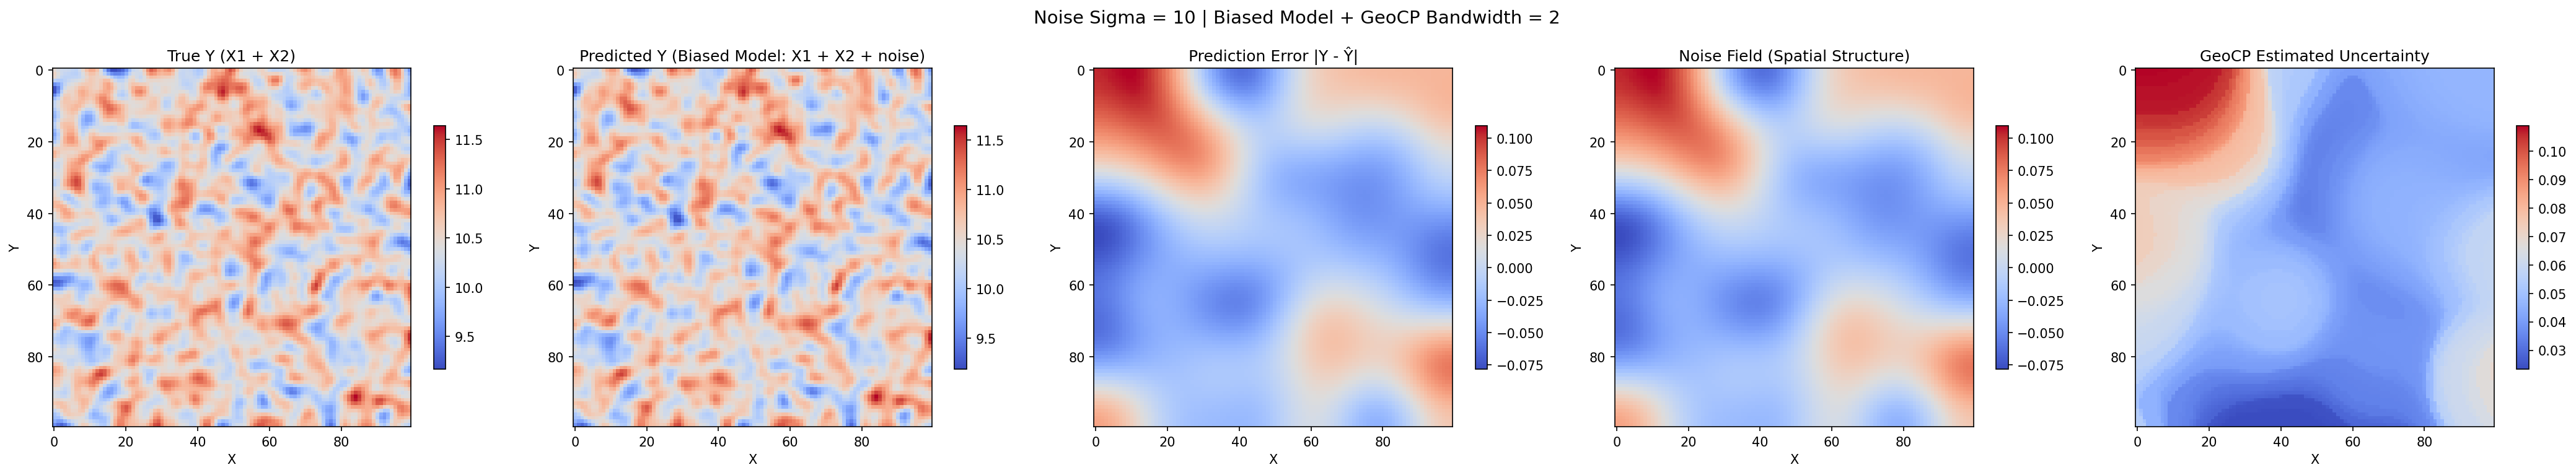

In [ ]:
import matplotlib.pyplot as plt
from GeoConformalSpatialRegression import GeoConformalSpatialRegression
fig, axes = plt.subplots(1, 5, figsize=(28, 5), dpi=150)
ax1, ax2, ax3, ax4, ax5 = axes

# True Y
c1 = ax1.imshow(true_y_grid, cmap='coolwarm')
fig.colorbar(c1, ax=ax1, shrink=0.6)
ax1.set_title("True Y (X1 + X2)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")

# Predicted Y
c2 = ax2.imshow(y_pred, cmap='coolwarm')
fig.colorbar(c2, ax=ax2, shrink=0.6)
ax2.set_title("Predicted Y (Biased Model: X1 + X2 + noise)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")

# Prediction Error
c3 = ax3.imshow(y_error, cmap='coolwarm')
fig.colorbar(c3, ax=ax3, shrink=0.6)
ax3.set_title("Prediction Error |Y - Ŷ|")
ax3.set_xlabel("X")
ax3.set_ylabel("Y")

# Noise Field
c4 = ax4.imshow(noise_grid, cmap='coolwarm')
fig.colorbar(c4, ax=ax4, shrink=0.6)
ax4.set_title("Noise Field (Spatial Structure)")
ax4.set_xlabel("X")
ax4.set_ylabel("Y")

# GeoCP Uncertainty
c5 = ax5.imshow(geo_uncertainty, cmap='coolwarm')
fig.colorbar(c5, ax=ax5, shrink=0.6)
ax5.set_title("GeoCP Estimated Uncertainty")
ax5.set_xlabel("X")
ax5.set_ylabel("Y")

plt.suptitle(f"Noise Sigma = {noise_sigma} | Biased Model + GeoCP Bandwidth = 2", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# 手动重算校准误差
y_calib_pred = predict_f(X_spatial_val)
nonconformity_scores = np.abs(y_calib_pred - y_val)

print("Nonconformity score (mean):", nonconformity_scores.mean())
print("Nonconformity score (std):", nonconformity_scores.std())

Nonconformity score (mean): 0.03189793248524951
Nonconformity score (std): 0.02209170971017823


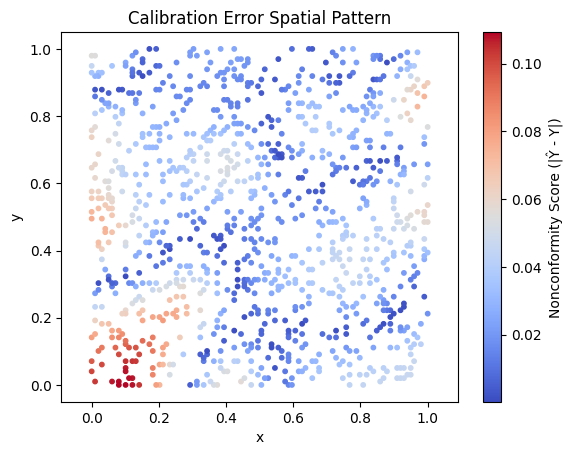

In [ ]:
import matplotlib.pyplot as plt

error_val = np.abs(predict_f(X_spatial_val) - y_val)
plt.scatter(loc_val["x_coord"], loc_val["y_coord"], c=error_val, cmap="coolwarm", s=10)
plt.colorbar(label="Nonconformity Score (|Ŷ - Y|)")
plt.title("Calibration Error Spatial Pattern")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

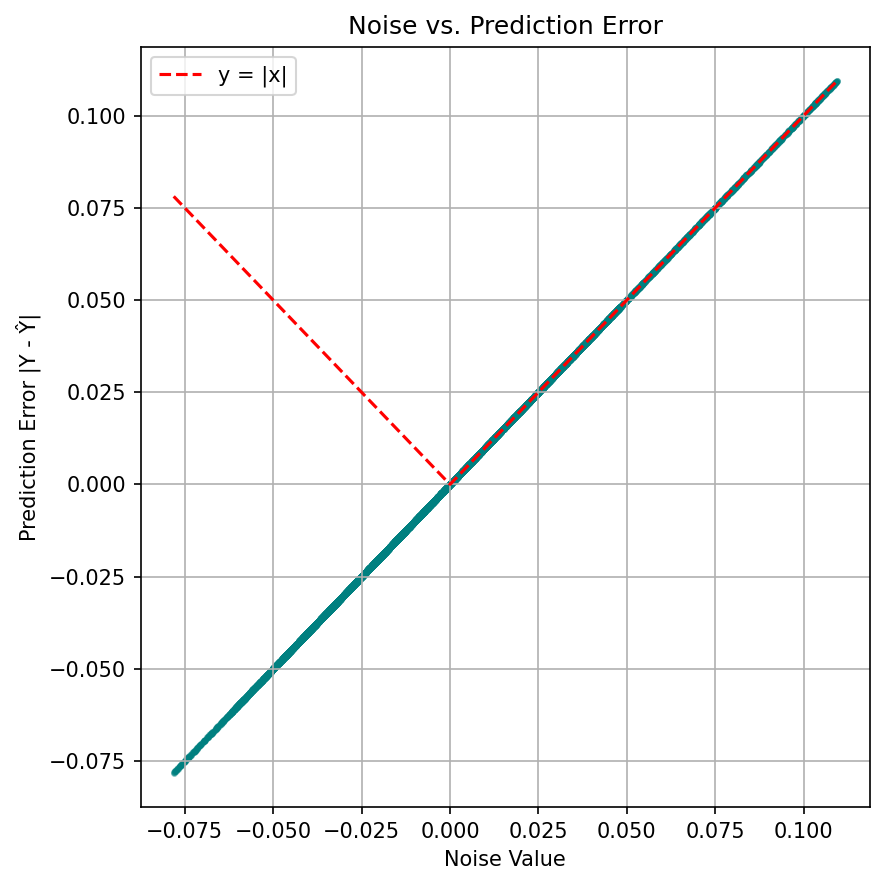

In [ ]:
import matplotlib.pyplot as plt

# 扁平化为 1D 向量
noise_flat = noise_grid.flatten()
error_flat = y_error.flatten()

# 散点图
plt.figure(figsize=(6, 6), dpi=150)
plt.scatter(noise_flat, error_flat, s=5, alpha=0.5, c='teal')
plt.xlabel("Noise Value")
plt.ylabel("Prediction Error |Y - Ŷ|")
plt.title("Noise vs. Prediction Error")
plt.grid(True)

# 添加参考线：y = |x|
x = np.linspace(noise_flat.min(), noise_flat.max(), 500)
plt.plot(x, np.abs(x), color='red', linestyle='--', linewidth=1.5, label="y = |x|")
plt.legend()
plt.tight_layout()
plt.show()

## 批量

In [ ]:
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from skimage.metrics import structural_similarity
# -----------------------
# 设定噪声平滑参数列表
# -----------------------
noise_sigmas = [1, 2, 3, 4, 5, 6, 7, 8]
results_summary = []

for noise_sigma in noise_sigmas:
    print(f"Running GeoCP for noise_sigma = {noise_sigma}...")

    # 1. 生成新的空间噪声
    df_coord_to_noise = create_coord_noise_df(
        X_coords=X_coords,
        grid_size=100,
        noise_std=10,
        sigma=noise_sigma,
        seed=42
    )

    # 2. 重新定义 biased predict function（绑定新的 noise）
    predict_f = lambda X_df: biased_model_predict(X_df, df_coord_to_feat, df_coord_to_noise)

    # 3. 重新建立 GeoCP 模型

    geocp_spatial_biased = GeoConformalSpatialRegression(
    predict_f=predict_f,
    miscoverage_level=0.1,
    bandwidth=0.1,
    coord_calib=coord_calib,
    coord_test=coord_test,
    X_calib=X_calib,
    y_calib=y_calib,
    X_test=X_test,
    y_test=y_test
)


    results_biased = geocp_spatial_biased.analyze()
    results_geo_biased = results_biased.to_gpd()

    # 4. 提取结果
    geo_uncertainty = results_geo_biased["geo_uncertainty"].values.reshape(100, 100)
    y_pred = biased_model_predict(X_coords, df_coord_to_feat, df_coord_to_noise).reshape(100, 100)
    noise_grid = df_coord_to_noise["noise"].values.reshape(100, 100)
    true_y_grid = true_y.reshape(100, 100)
    y_error = np.abs(true_y_grid - y_pred)

    # 5. 计算统计指标
    coverage_rate = results_biased.coverage_probability
    noise_moran_i = compute_moran(noise_grid)
    data_moran_i = compute_moran(true_y_grid)
    rmse = root_mean_squared_error(np.abs(noise_grid), geo_uncertainty)
    corr = np.corrcoef(np.abs(noise_grid).flatten(), geo_uncertainty.flatten())[0, 1]
    ssim = structural_similarity(
        np.abs(noise_grid),
        geo_uncertainty,
        data_range=np.ptp(np.abs(noise_grid))
    )

    # 保存当前结果
    results_summary.append({
        "noise_sigma": noise_sigma,
        "rmse": rmse,
        "corr": corr,
        "ssim": ssim,
        "noise_moran": noise_moran_i,
        "data_moran": data_moran_i,
        "coverage_rate": coverage_rate
    })

    # 6. 可视化（2行3列子图）
    fig, axes = plt.subplots(2, 3, figsize=(18, 8), dpi=300)
    ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

    # True Y
    c1 = ax1.imshow(true_y_grid, cmap='coolwarm')
    fig.colorbar(c1, ax=ax1, shrink=0.5)
    ax1.set_title('True Y')

    # Predicted Y
    c2 = ax2.imshow(y_pred, cmap='coolwarm')
    fig.colorbar(c2, ax=ax2, shrink=0.5)
    ax2.set_title('Predicted Y (Biased Model)')

    # Prediction Error
    c3 = ax3.imshow(y_error, cmap='coolwarm')
    fig.colorbar(c3, ax=ax3, shrink=0.5)
    ax3.set_title('Prediction Error |Y - Ŷ|')

    # GeoCP Uncertainty
    c4 = ax4.imshow(geo_uncertainty, cmap='coolwarm')
    fig.colorbar(c4, ax=ax4, shrink=0.5)
    ax4.set_title('GeoCP Uncertainty')

    # Noise Field
    c5 = ax5.imshow(noise_grid, cmap='coolwarm')
    fig.colorbar(c5, ax=ax5, shrink=0.5)
    ax5.set_title('Noise Field')

    # Absolute Noise
    c6 = ax6.imshow(np.abs(noise_grid), cmap='coolwarm')
    fig.colorbar(c6, ax=ax6, shrink=0.5)
    ax6.set_title('Abs(Noise)')

    fig.suptitle(
        f'Noise Sigma={noise_sigma}, RMSE={rmse:.4f}, Corr={corr:.4f}, SSIM={ssim:.4f}, '
        f'Data Moran={data_moran_i:.4f}, Noise Moran={noise_moran_i:.4f}, Coverage={coverage_rate:.4f}',
        fontsize=12
    )
    plt.tight_layout()
    plt.show()
    plt.close()

# 7. 保存所有统计指标
results_df = pd.DataFrame(results_summary)
results_df.to_csv("geoCP_biased_model_results.csv", index=False)

print("✅ All experiments completed and results saved.")

Running GeoCP for noise_sigma = 1...


KeyboardInterrupt: 

## GeoSIMcp test


In [ ]:
# 基础数据
grid_size = 100
x = np.linspace(0, 1, grid_size)
y = np.linspace(0, 1, grid_size)
X_grid, Y_grid = np.meshgrid(x, y)
coords = np.stack([X_grid.ravel(), Y_grid.ravel()], axis=1)
X_coords = pd.DataFrame(coords, columns=["x_coord", "y_coord"])

np.random.seed(42)
X1 = gaussian_filter(np.random.uniform(5, 10, size=(grid_size, grid_size)), sigma=5).flatten()
X2 = gaussian_filter(np.random.uniform(0, 6, size=(grid_size, grid_size)), sigma=1.5).flatten()

true_y = X1 + X2
noise = np.random.normal(0, 1, size=true_y.shape)

df_coord_to_feat = X_coords.copy()
df_coord_to_feat["X1"] = X1
df_coord_to_feat["X2"] = X2

df_coord_to_noise = X_coords.copy()
df_coord_to_noise["noise"] = noise

# 拆分
X_spatial_train, X_spatial_temp, X_aspatial_train, X_aspatial_temp, y_train, y_temp, loc_train, loc_temp = train_test_split(
    X_coords, np.vstack([X1, X2]).T, true_y, X_coords, train_size=0.8, random_state=42
)
X_spatial_val, X_spatial_test, X_aspatial_val, X_aspatial_test, y_val, y_test, loc_val, loc_test = train_test_split(
    X_spatial_temp, X_aspatial_temp, y_temp, loc_temp, train_size=0.5, random_state=42
)

# GeoCP输入
X_calib = loc_val.copy()        # 只要 x_coord, y_coord
X_test = X_coords.copy()
y_calib = y_val
y_test = true_y
coord_calib = loc_val.values
coord_test = X_coords.values

# predict_f
predict_f = lambda X_df: biased_model_predict(X_df, df_coord_to_feat, df_coord_to_noise)

print("✅ 全部准备就绪")

✅ 全部准备就绪


In [ ]:
from GeoSIMCP import GeoSIMConformalSpatialRegression
# 1. 创建空间噪声
noise_sigma = 1

df_coord_to_noise = create_coord_noise_df(
    X_coords=X_coords,
    grid_size=100,
    noise_std=1,
    sigma=noise_sigma,
    seed=42
)

df_coord_to_noise = create_coord_noise_df(
    X_coords=X_coords,
    grid_size=100,
    noise_std=1,
    sigma=noise_sigma,
    seed=42,
    correlate_with_y=False          # ✅ 关闭
)

df_coord_to_noise = create_coord_noise_df(
    X_coords=X_coords,
    grid_size=100,
    noise_std=1,
    sigma=noise_sigma,
    seed=42,
    correlate_with_y=True,         # ✅ 开启相关性
    true_y=true_y,                 # ✅ 传入你的真实Y
    correlation_strength=0.1       # ✅ 控制强度（越大越相关，最大1.0）
)


df_coord_to_noise = create_coord_noise_df(
    X_coords=X_coords,
    grid_size=100,
    noise_std=1,
    feature_space_cluster=True,
    X_features=np.vstack([X1, X2]).T,
    cluster_center=(7, 2),
    cluster_width=0.5,
    seed=42
)
# 2. 建立查表 df
df_coord_to_feat = X_coords.copy()
df_coord_to_feat["X1"] = X1
df_coord_to_feat["X2"] = X2

# 3. 定义 biased predict function
predict_f = lambda X_df: biased_model_predict(X_df, df_coord_to_feat, df_coord_to_noise)

# 4. 运行 GeoCP
geocp_spatial_biased = GeoConformalSpatialRegression(
    predict_f=predict_f,
    miscoverage_level=0.1,
    bandwidth=0.1,
    coord_calib=coord_calib,
    coord_test=coord_test,
    X_calib=X_calib,
    y_calib=y_calib,
    X_test=X_test,
    y_test=y_test
)

geocp_spatial_biased = GeoConformalSpatialRegression(
    predict_f=predict_f,
    miscoverage_level=0.1,
    bandwidth=0.1,
    coord_calib=coord_calib,
    coord_test=coord_test,
    X_calib=X_calib,
    y_calib=y_calib,
    X_test=X_test,
    y_test=y_test
)


results_biased_geocp = geocp_spatial_biased.analyze()
results_geo_geocp = results_biased_geocp.to_gpd()

# 5. 提取 GeoCP结果
geo_uncertainty_geocp = results_geo_geocp["geo_uncertainty"].values.reshape(100, 100)
y_pred_geocp = biased_model_predict(X_coords, df_coord_to_feat, df_coord_to_noise).reshape(100, 100)

# 6. 运行 GeoSIMCP

# 🛠️ 准备 GeoSIMCP输入
# 先保证所有东西都是 DataFrame
# X_spatial：只含 x_coord, y_coord
X_calib = loc_val.copy()
X_test = X_coords.copy()

# X_aspatial：只含 X1, X2
X_calib_weight = pd.DataFrame(X_aspatial_val, columns=["X1", "X2"])
X_test_weight = pd.DataFrame(X_aspatial_test, columns=["X1", "X2"])

# coord：loc_val和loc是原本的
coord_calib = loc_val.values
coord_test = loc_test.values

# 先建好一万个点的特征X_features
X_features = np.vstack([X1, X2]).T

# GeoSIMCP 输入
geosimcp_spatial_biased = GeoSIMConformalSpatialRegression(
    predict_f=predict_f,
    miscoverage_level=0.1,
    bandwidth=0.1,
    lambda_weight=0,
    coord_calib=loc_val.values,
    coord_test=X_coords.values,               # ✅ 改成一万个
    X_calib=loc_val.copy(),
    X_test=X_coords.copy(),
    X_calib_weight=pd.DataFrame(X_aspatial_val, columns=["X1", "X2"]),
    X_test_weight=pd.DataFrame(X_features, columns=["X1", "X2"]),  # ✅ 改成一万个
    y_calib=y_val,
    y_test=true_y  # ✅ 一万个
)
results_biased_geosimcp = geosimcp_spatial_biased.analyze()
results_geo_geosimcp = results_biased_geosimcp.to_gpd()

# 7. 提取 GeoSIMCP结果
geo_uncertainty_geosimcp = results_geo_geosimcp["geo_uncertainty"].values.reshape(100, 100)
y_pred_geosimcp = biased_model_predict(X_coords, df_coord_to_feat, df_coord_to_noise).reshape(100, 100)

# 8. 其他公共变量
noise_grid = df_coord_to_noise["noise"].values.reshape(100, 100)
true_y_grid = true_y.reshape(100, 100)
y_error = np.abs(true_y_grid - y_pred_geocp)  # 误差可以统一用 GeoCP的预测来算

=== GeoCP Metrics ===
Coverage: 0.8948
Mean Uncertainty: 0.2578
RMSE (vs Abs(Noise)): 0.2298
Corr (vs Abs(Noise)): 0.1075
SSIM (vs Abs(Noise)): 0.1536

=== GeoSIMCP Metrics ===
Coverage: 0.8485
Mean Uncertainty: 0.1793
RMSE (vs Abs(Noise)): 0.1782
Corr (vs Abs(Noise)): 0.6021
SSIM (vs Abs(Noise)): 0.5078


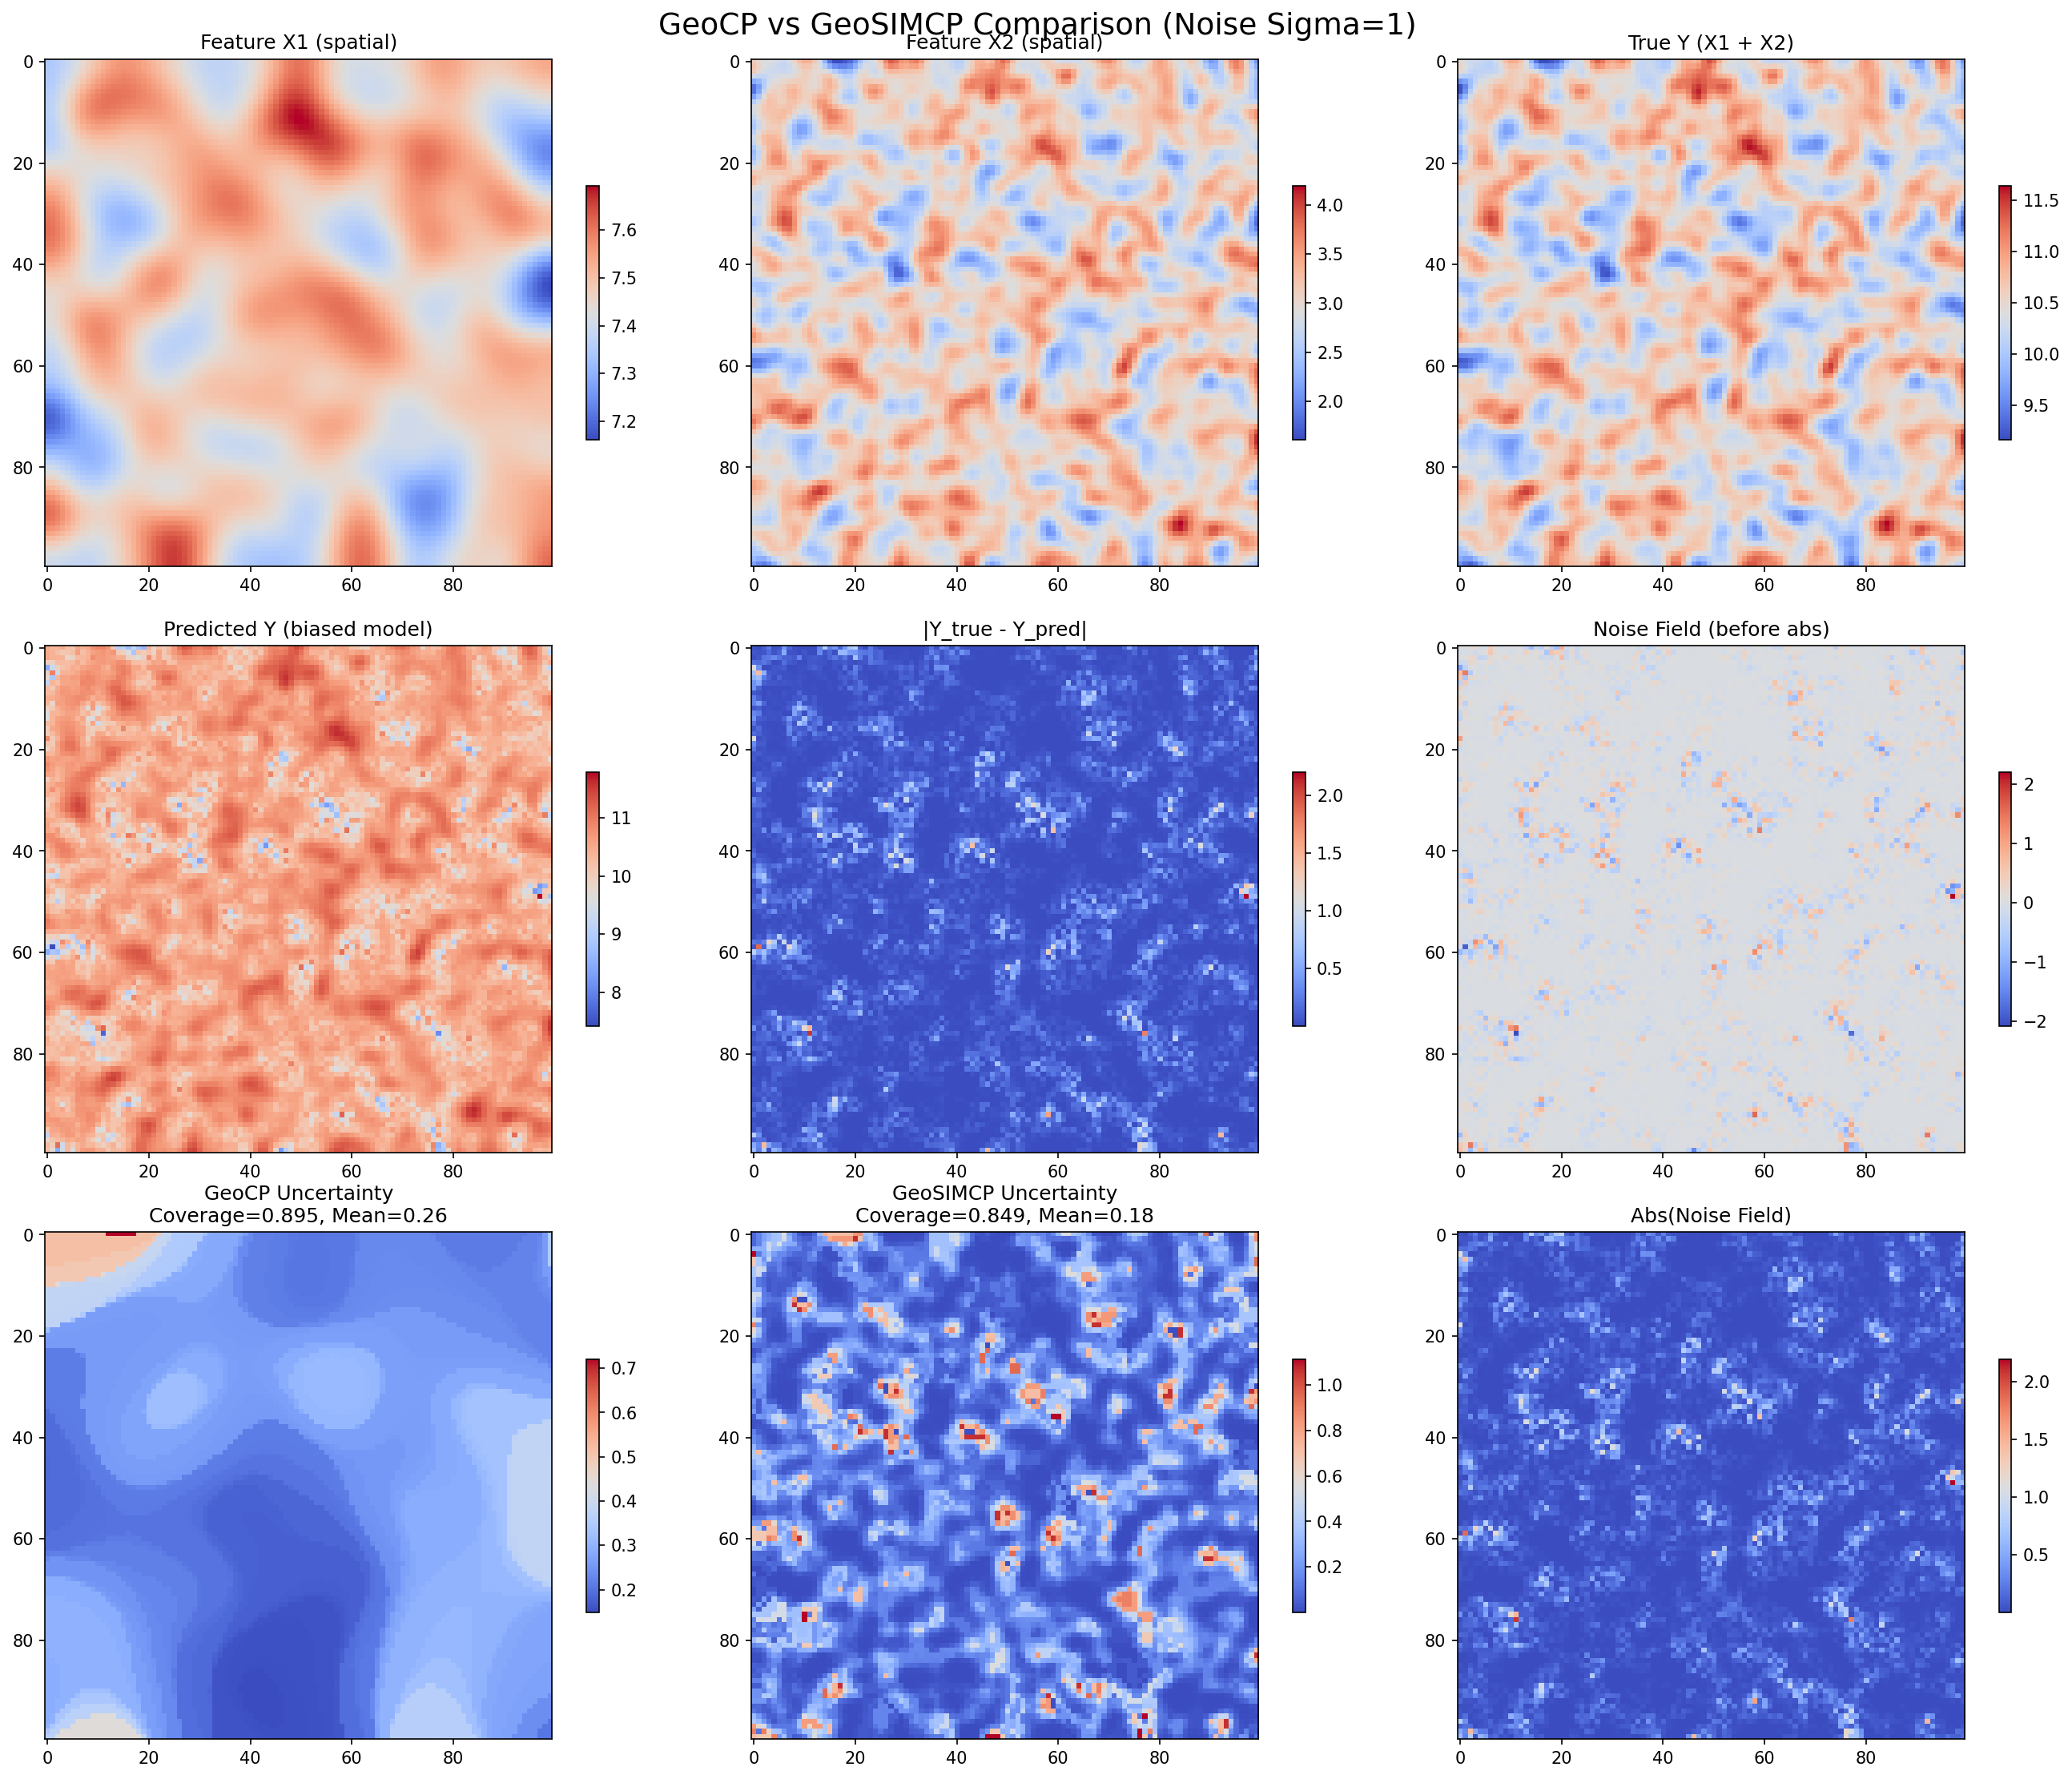

In [ ]:
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity
import numpy as np
import pandas as pd

# 9. 统一处理
noise_abs = np.abs(noise_grid)
geo_uncertainty_geocp_flat = geo_uncertainty_geocp.flatten()
geo_uncertainty_geosimcp_flat = geo_uncertainty_geosimcp.flatten()
noise_abs_flat = noise_abs.flatten()

# 10. 计算指标
from sklearn.metrics import mean_squared_error

def root_mean_squared_error(a, b):
    return np.sqrt(mean_squared_error(a.flatten(), b.flatten()))

def compute_corr(a, b):
    return np.corrcoef(a.flatten(), b.flatten())[0, 1]

def compute_ssim(a, b):
    return structural_similarity(a, b, data_range=np.ptp(a))

# GeoCP指标
rmse_geocp = root_mean_squared_error(noise_abs, geo_uncertainty_geocp)
corr_geocp = compute_corr(noise_abs, geo_uncertainty_geocp)
ssim_geocp = compute_ssim(noise_abs, geo_uncertainty_geocp)
coverage_geocp = results_biased_geocp.coverage_probability
mean_uncertainty_geocp = np.mean(geo_uncertainty_geocp)

# GeoSIMCP指标
rmse_geosimcp = root_mean_squared_error(noise_abs, geo_uncertainty_geosimcp)
corr_geosimcp = compute_corr(noise_abs, geo_uncertainty_geosimcp)
ssim_geosimcp = compute_ssim(noise_abs, geo_uncertainty_geosimcp)
coverage_geosimcp = results_biased_geosimcp.coverage_probability
mean_uncertainty_geosimcp = np.mean(geo_uncertainty_geosimcp)

# 11. 打印指标
print("=== GeoCP Metrics ===")
print(f"Coverage: {coverage_geocp:.4f}")
print(f"Mean Uncertainty: {mean_uncertainty_geocp:.4f}")
print(f"RMSE (vs Abs(Noise)): {rmse_geocp:.4f}")
print(f"Corr (vs Abs(Noise)): {corr_geocp:.4f}")
print(f"SSIM (vs Abs(Noise)): {ssim_geocp:.4f}")

print("\n=== GeoSIMCP Metrics ===")
print(f"Coverage: {coverage_geosimcp:.4f}")
print(f"Mean Uncertainty: {mean_uncertainty_geosimcp:.4f}")
print(f"RMSE (vs Abs(Noise)): {rmse_geosimcp:.4f}")
print(f"Corr (vs Abs(Noise)): {corr_geosimcp:.4f}")
print(f"SSIM (vs Abs(Noise)): {ssim_geosimcp:.4f}")

# 12. 可视化 (3行3列)
fig, axes = plt.subplots(3, 3, figsize=(18, 15), dpi=150)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9 = axes.ravel()

# X1
c1 = ax1.imshow(X1.reshape(100, 100), cmap='coolwarm')
fig.colorbar(c1, ax=ax1, shrink=0.5)
ax1.set_title("Feature X1 (spatial)")

# X2
c2 = ax2.imshow(X2.reshape(100, 100), cmap='coolwarm')
fig.colorbar(c2, ax=ax2, shrink=0.5)
ax2.set_title("Feature X2 (spatial)")

# True Y
c3 = ax3.imshow(true_y_grid, cmap='coolwarm')
fig.colorbar(c3, ax=ax3, shrink=0.5)
ax3.set_title("True Y (X1 + X2)")

# Predicted Y
c4 = ax4.imshow(y_pred_geocp, cmap='coolwarm')
fig.colorbar(c4, ax=ax4, shrink=0.5)
ax4.set_title("Predicted Y (biased model)")

# Prediction Error
c5 = ax5.imshow(y_error, cmap='coolwarm')
fig.colorbar(c5, ax=ax5, shrink=0.5)
ax5.set_title("|Y_true - Y_pred|")

# Noise Field
c6 = ax6.imshow(noise_grid, cmap='coolwarm')
fig.colorbar(c6, ax=ax6, shrink=0.5)
ax6.set_title("Noise Field (before abs)")

# GeoCP Uncertainty
c7 = ax7.imshow(geo_uncertainty_geocp, cmap='coolwarm')
fig.colorbar(c7, ax=ax7, shrink=0.5)
ax7.set_title(f"GeoCP Uncertainty\nCoverage={coverage_geocp:.3f}, Mean={mean_uncertainty_geocp:.2f}")

# GeoSIMCP Uncertainty
c8 = ax8.imshow(geo_uncertainty_geosimcp, cmap='coolwarm')
fig.colorbar(c8, ax=ax8, shrink=0.5)
ax8.set_title(f"GeoSIMCP Uncertainty\nCoverage={coverage_geosimcp:.3f}, Mean={mean_uncertainty_geosimcp:.2f}")

# Abs(Noise Field)
c9 = ax9.imshow(noise_abs, cmap='coolwarm')
fig.colorbar(c9, ax=ax9, shrink=0.5)
ax9.set_title("Abs(Noise Field)")

fig.suptitle(f"GeoCP vs GeoSIMCP Comparison (Noise Sigma={noise_sigma})", fontsize=18)
plt.tight_layout()
plt.show()

# ✅ 如果要保存高质量版
# plt.savefig('comparison_geocp_geosimcp_fullgrid.pdf', dpi=300)

# 测试GeoSIMCP和GeoCP的参数最优化

In [88]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# ===================================
# ✨ 1. interval_score
# ===================================
def interval_score(y_true, lower, upper, alpha=0.1, epsilon=1e-6):
    """
    Interval score for prediction intervals
    """
    width = np.maximum(upper - lower, epsilon)
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    return width + (2 / alpha) * (below + above)

# ===================================
# ✨ 2. GeoCP的bandwidth sweep
# ===================================
def bandwidth_grid_sweep_geocp(
    bandwidth_list,
    predict_f,
    X_val,
    X_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    noise_abs=None,
    alpha=0.1,
    coverage_threshold=0.9
):
    from GeoConformalSpatialRegression import GeoConformalSpatialRegression  # 确保有这个类

    coverage_list = []
    uncertainty_list = []
    interval_score_list = []
    rmse_list = []
    r2_list = []

    for bw in bandwidth_list:
        model = GeoConformalSpatialRegression(
            predict_f=predict_f,
            miscoverage_level=alpha,
            bandwidth=bw,
            coord_calib=loc_val.values,
            coord_test=loc_test.values,
            X_calib=X_val,
            y_calib=y_val,
            X_test=X_test,
            y_test=y_test
        )

        result = model.analyze()
        coverage_list.append(result.coverage_probability)

        unc = np.array(result.geo_uncertainty)
        unc = unc[~np.isnan(unc)]
        uncertainty_list.append(np.mean(unc) if len(unc) > 0 else np.nan)

        lower = np.array(result.lower_bound)
        upper = np.array(result.upper_bound)
        y_true = np.array(y_test)

        score = interval_score(y_true, lower, upper, alpha=alpha)
        interval_score_list.append(np.mean(score))

        if noise_abs is not None:
            geo_uncertainty = result.geo_uncertainty.reshape(noise_abs.shape)
            rmse = np.sqrt(mean_squared_error(noise_abs.flatten(), geo_uncertainty.flatten()))
            rmse_list.append(rmse)
            r2 = r2_score(noise_abs.flatten(), geo_uncertainty.flatten())
            r2_list.append(r2)
        else:
            rmse_list.append(np.nan)
            r2_list.append(np.nan)

    mask = np.array(coverage_list) >= coverage_threshold
    masked_score = np.where(mask, interval_score_list, np.inf)
    best_idx = np.argmin(masked_score)
    best_bw = bandwidth_list[best_idx]

    print(f"✅ GeoCP Optimal Parameters Summary:")
    print(f"  Best Bandwidth   = {best_bw:.3f}")
    print(f"  Coverage         = {coverage_list[best_idx]:.3f}")
    print(f"  Interval Score   = {interval_score_list[best_idx]:.3f}")
    print(f"  Mean Uncertainty = {uncertainty_list[best_idx]:.3f}")
    print(f"  RMSE             = {rmse_list[best_idx]:.3f}")
    print(f"  R²               = {r2_list[best_idx]:.3f}")

    return {
        'coverage': coverage_list[best_idx],
        'interval_score': interval_score_list[best_idx],
        'mean_uncertainty': uncertainty_list[best_idx],
        'rmse': rmse_list[best_idx],
        'r2': r2_list[best_idx],
        'nrmse': rmse_list[best_idx] / (noise_abs.max() - noise_abs.min()) if noise_abs is not None else np.nan,
        'best_bandwidth': best_bw
    }

# ===================================
# ✨ 3. GeoSIMCP的bandwidth × lambda sweep
# ===================================
def select_best_lambda_bandwidth(coverage_grid, score_grid, lambda_list, bandwidth_list, threshold=0.9):
    mask = coverage_grid >= threshold
    masked_score = np.where(mask, score_grid, np.inf)
    idx = np.unravel_index(np.argmin(masked_score), masked_score.shape)
    best_lambda = lambda_list[idx[1]]
    best_bandwidth = bandwidth_list[idx[0]]
    return best_lambda, best_bandwidth, masked_score[idx], idx

def geosimcp_bandwidth_lambda_grid_sweep(
    bandwidth_list,
    lambda_list,
    predict_f,
    X_spatial_val,
    X_spatial_test,
    X_aspatial_val,
    X_aspatial_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    noise_abs=None,
    alpha=0.1,
    coverage_threshold=0.9
):
    from GeoSIMCP import GeoSIMConformalSpatialRegression  # 确保有这个类

    coverage_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    uncertainty_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    interval_score_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    rmse_grid = np.full_like(interval_score_grid, np.nan)
    r2_grid = np.full_like(interval_score_grid, np.nan)

    for i, bw in enumerate(bandwidth_list):
        for j, lam in enumerate(lambda_list):
            try:
                model = GeoSIMConformalSpatialRegression(
                    predict_f=predict_f,
                    miscoverage_level=alpha,
                    bandwidth=bw,
                    coord_calib=loc_val.values,
                    coord_test=loc_test.values,
                    X_calib=X_spatial_val,
                    X_test=X_spatial_test,
                    y_calib=y_val,
                    y_test=y_test,
                    X_calib_weight=X_aspatial_val,
                    X_test_weight=X_aspatial_test,
                    lambda_weight=lam
                )
                result = model.analyze()

                coverage_grid[i, j] = result.coverage_probability
                uncertainty_grid[i, j] = np.mean(result.geo_uncertainty)

                lower = np.array(result.lower_bound)
                upper = np.array(result.upper_bound)
                y_true = np.array(y_test)

                score = interval_score(y_true, lower, upper, alpha=alpha)
                interval_score_grid[i, j] = np.mean(score)

                if noise_abs is not None:
                    geo_uncertainty = result.geo_uncertainty.reshape(noise_abs.shape)
                    rmse_grid[i, j] = np.sqrt(mean_squared_error(noise_abs.flatten(), geo_uncertainty.flatten()))
                    r2_grid[i, j] = r2_score(noise_abs.flatten(), geo_uncertainty.flatten())

            except Exception as e:
                print(f"❌ Model failed at bandwidth={bw:.3f}, lambda={lam:.3f}")
                print(f"   Error: {str(e)}")
                continue

    best_lambda, best_bw, best_score, idx = select_best_lambda_bandwidth(
        coverage_grid, interval_score_grid, lambda_list, bandwidth_list, threshold=coverage_threshold
    )
    best_coverage = coverage_grid[idx]
    best_uncertainty = uncertainty_grid[idx]

    print("\n✅ GeoSIMCP Optimal Parameters Summary:")
    print(f"  Best Bandwidth  = {best_bw:.3f}")
    print(f"  Best Lambda     = {best_lambda:.3f}")
    print(f"  Coverage        = {best_coverage:.3f}")
    print(f"  Interval Score  = {best_score:.3f}")
    print(f"  Mean Uncertainty= {best_uncertainty:.3f}")
    if noise_abs is not None:
        print(f"  RMSE            = {rmse_grid[idx]:.3f}")
        print(f"  R2              = {r2_grid[idx]:.3f}")

    return {
        'coverage': best_coverage,
        'interval_score': best_score,
        'mean_uncertainty': best_uncertainty,
        'rmse': rmse_grid[idx],
        'r2': r2_grid[idx],
        'nrmse': rmse_grid[idx] / (noise_abs.max() - noise_abs.min()) if noise_abs is not None else np.nan,
        'best_bandwidth': best_bw,
        'best_lambda': best_lambda
    }

In [89]:

def batch_run_geocp_geosimcp(
    noise_sigma_list,
    grid_size,
    base_X_coords,
    X1,
    X2,
    true_y,
    df_coord_to_feat,
    create_coord_noise_df,
    biased_model_predict,
    bandwidth_list_geocp,
    bandwidth_list_geosimcp,
    lambda_list_geosimcp,
    alpha=0.1,
    coverage_threshold=0.9,
    save_prefix="geo_cp_vs_simcp_batch"
):
    results = []

    for noise_sigma in tqdm(noise_sigma_list, desc="Batch Running"):
        # 1. 生成对应噪声
        # df_coord_to_noise = create_coord_noise_df(
        #     X_coords=base_X_coords,
        #     grid_size=grid_size,
        #     noise_std=1,
        #     sigma=noise_sigma,
        #     seed=42
        # )

        df_coord_to_noise = create_coord_noise_df(
            X_coords=X_coords,
            grid_size=100,
            noise_std=1,
            sigma=noise_sigma,
            seed=42,
            correlate_with_y=True,         # ✅ 开启相关性
            true_y=true_y,                 # ✅ 传入你的真实Y
            correlation_strength=0.1       # ✅ 控制强度（越大越相关，最大1.0）
        )


        df_coord_to_noise = create_coord_noise_df(
            X_coords=X_coords,
            grid_size=100,
            noise_std=1,
            feature_space_cluster=True,
            X_features=np.vstack([X1, X2]).T,
            cluster_center=(7, 2),
            cluster_width=0.5,
            seed=42
        )
        # 2. 构建predict函数
        predict_f = lambda X_df: biased_model_predict(X_df, df_coord_to_feat, df_coord_to_noise)

        # 3. 基础变量准备
        X_features = np.vstack([X1, X2]).T
        noise_abs = np.abs(df_coord_to_noise["noise"].values.reshape(100, 100))

        # 4. GeoCP tuning
        geocp_metrics = bandwidth_grid_sweep_geocp(
            bandwidth_list=bandwidth_list_geocp,
            predict_f=predict_f,
            X_val=loc_val,
            X_test=X_coords,
            y_val=y_val,
            y_test=true_y,
            loc_val=loc_val,
            loc_test=X_coords,
            noise_abs=noise_abs,
            alpha=alpha,
            coverage_threshold=coverage_threshold
        )

        # 5. GeoSIMCP tuning
        geosimcp_metrics = geosimcp_bandwidth_lambda_grid_sweep(
            bandwidth_list=bandwidth_list_geosimcp,
            lambda_list=lambda_list_geosimcp,
            predict_f=predict_f,
            X_spatial_val=loc_val,
            X_spatial_test=X_coords,
            X_aspatial_val=pd.DataFrame(X_aspatial_val, columns=["X1", "X2"]),
            X_aspatial_test=pd.DataFrame(X_features, columns=["X1", "X2"]),
            y_val=y_val,
            y_test=true_y,
            loc_val=loc_val,
            loc_test=X_coords,
            noise_abs=noise_abs,
            alpha=alpha,
            coverage_threshold=coverage_threshold
        )

        # 6. 保存每次结果
        results.append({
            'noise_sigma': noise_sigma,
            'method': 'GeoCP',
            **geocp_metrics
        })
        results.append({
            'noise_sigma': noise_sigma,
            'method': 'GeoSIMCP',
            **geosimcp_metrics
        })

    # 汇总所有结果
    results_df = pd.DataFrame(results)

    # 保存csv
    results_df.to_csv(f"{save_prefix}_metrics.csv", index=False)
    print(f"✅ All results saved to {save_prefix}_metrics.csv")

    return results_df

def plot_batch_results(results_df, save_prefix="geo_cp_vs_simcp_batch"):
    indicators = ['coverage', 'interval_score', 'mean_uncertainty', 'rmse', 'r2']

    for indicator in indicators:
        plt.figure(figsize=(6, 4), dpi=150)
        for method in results_df['method'].unique():
            subset = results_df[results_df['method'] == method]
            plt.plot(subset['noise_sigma'], subset[indicator], label=method, marker='o')

        plt.title(f"{indicator} vs Noise Sigma")
        plt.xlabel("Noise Sigma")
        plt.ylabel(indicator)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"{save_prefix}_{indicator}.pdf")
        plt.show()

In [ ]:
noise_sigma_list = [1.0]
noise_std_list = [0.5, 1.0, 2.0, 5.0]  # 噪声的绝对幅度，从弱到强

results_df = batch_run_geocp_geosimcp(
    noise_sigma_list=noise_sigma_list,
    noise_std_list=noise_std_list,
    grid_size=100,
    base_X_coords=X_coords,
    X1=X1,
    X2=X2,
    true_y=true_y,
    df_coord_to_feat=df_coord_to_feat,
    create_coord_noise_df=create_coord_noise_df,
    biased_model_predict=biased_model_predict,
    bandwidth_list_geocp=np.linspace(0.1, 1.5, 10),
    bandwidth_list_geosimcp=np.linspace(0.1, 1.5, 10),
    lambda_list_geosimcp=np.linspace(0, 1, 6),
    alpha=0.1,
    coverage_threshold=0.9,
    save_prefix="geo_cp_vs_simcp_batch"
)

plot_batch_results(results_df, save_prefix="geo_cp_vs_simcp_batch")

## new version

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

def batch_run_geocp_geosimcp(
    noise_sigma_list=None,
    noise_std_list=None,
    grid_size=100,
    base_X_coords=None,
    X1=None,
    X2=None,
    true_y=None,
    df_coord_to_feat=None,
    create_coord_noise_df=None,
    biased_model_predict=None,
    bandwidth_list_geocp=None,
    bandwidth_list_geosimcp=None,
    lambda_list_geosimcp=None,
    alpha=0.1,
    coverage_threshold=0.9,
    save_prefix="geo_cp_vs_simcp_batch",
    feature_space_noise=False    # ✅ 新增！决定是否用特征空间生成噪声
):
    results = []

    if noise_sigma_list is None:
        noise_sigma_list = [3.0]
    if noise_std_list is None:
        noise_std_list = [1.0]

    for noise_sigma in tqdm(noise_sigma_list, desc="Sigma Loop"):
        for noise_std in tqdm(noise_std_list, desc="STD Loop", leave=False):

            if feature_space_noise:
                # ✅ 特征空间聚集噪声
                X_features = np.vstack([X1, X2]).T
                df_coord_to_noise = create_coord_noise_df(
                    X_coords=base_X_coords,
                    grid_size=grid_size,
                    noise_std=noise_std,
                    sigma=noise_sigma,                  # 这个在feature_space里其实不怎么起作用，但统一传进去
                    feature_space_cluster=True,          # ✅ 开启
                    X_features=X_features,
                    cluster_center=(7, 2),               # 可以参数化
                    cluster_width=0.5,                   # 可以参数化
                    seed=42
                )
            else:
                # ✅ 地理空间高斯噪声
                df_coord_to_noise = create_coord_noise_df(
                    X_coords=base_X_coords,
                    grid_size=grid_size,
                    noise_std=noise_std,
                    sigma=noise_sigma,
                    seed=42
                )

            # 构建predict函数
            predict_f = lambda X_df: biased_model_predict(X_df, df_coord_to_feat, df_coord_to_noise)

            # 基础变量准备
            X_features = np.vstack([X1, X2]).T
            noise_abs = np.abs(df_coord_to_noise["noise"].values.reshape(grid_size, grid_size))

            # GeoCP tuning
            geocp_metrics = bandwidth_grid_sweep_geocp(
                bandwidth_list=bandwidth_list_geocp,
                predict_f=predict_f,
                X_val=loc_val,
                X_test=base_X_coords,
                y_val=y_val,
                y_test=true_y,
                loc_val=loc_val,
                loc_test=base_X_coords,
                noise_abs=noise_abs,
                alpha=alpha,
                coverage_threshold=coverage_threshold
            )

            # GeoSIMCP tuning
            geosimcp_metrics = geosimcp_bandwidth_lambda_grid_sweep(
                bandwidth_list=bandwidth_list_geosimcp,
                lambda_list=lambda_list_geosimcp,
                predict_f=predict_f,
                X_spatial_val=loc_val,
                X_spatial_test=base_X_coords,
                X_aspatial_val=pd.DataFrame(X_aspatial_val, columns=["X1", "X2"]),
                X_aspatial_test=pd.DataFrame(X_features, columns=["X1", "X2"]),
                y_val=y_val,
                y_test=true_y,
                loc_val=loc_val,
                loc_test=base_X_coords,
                noise_abs=noise_abs,
                alpha=alpha,
                coverage_threshold=coverage_threshold
            )

            # 保存每次结果
            results.append({
                'noise_sigma': noise_sigma,
                'noise_std': noise_std,
                'method': 'GeoCP',
                **geocp_metrics
            })
            results.append({
                'noise_sigma': noise_sigma,
                'noise_std': noise_std,
                'method': 'GeoSIMCP',
                **geosimcp_metrics
            })

    # 汇总所有结果
    results_df = pd.DataFrame(results)

    results_df.to_csv(f"{save_prefix}_metrics.csv", index=False)
    print(f"✅ All results saved to {save_prefix}_metrics.csv")

    return results_df


def plot_batch_results(
    results_df,
    save_prefix="geo_cp_vs_simcp_batch",
    x_axis="noise_std",           # ✅ 新增参数，默认横轴是noise_std
    fixed_value=None,             # ✅ 可选，固定另一个参数，比如固定noise_sigma=3
    fixed_param="noise_sigma"     # ✅ 默认固定noise_sigma
):
    """
    绘制 batch 实验结果
    - x_axis: 选择横轴是 'noise_std' 或 'noise_sigma'
    - fixed_value: 如果指定，表示只绘制固定另一个参数取特定值的子集
    - fixed_param: 指定固定哪个参数，'noise_sigma' 或 'noise_std'
    """

    indicators = ['coverage', 'interval_score', 'mean_uncertainty', 'rmse', 'r2']

    for indicator in indicators:
        plt.figure(figsize=(6, 4), dpi=150)

        for method in results_df['method'].unique():
            subset = results_df[results_df['method'] == method]

            # 如果指定了固定值，只画满足条件的子集
            if fixed_value is not None:
                subset = subset[subset[fixed_param] == fixed_value]

            subset = subset.sort_values(by=x_axis)

            plt.plot(subset[x_axis], subset[indicator], label=method, marker='o')

        plt.title(f"{indicator} vs {x_axis.replace('_', ' ').title()}")
        plt.xlabel(x_axis.replace('_', ' ').title())
        plt.ylabel(indicator)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        # 文件名也反映x轴和固定的参数
        save_name = f"{save_prefix}_{indicator}_x-{x_axis}"
        if fixed_value is not None:
            save_name += f"_fixed-{fixed_param}-{fixed_value}"

        plt.savefig(f"{save_name}.pdf")
        plt.show()


In [97]:
results_df = batch_run_geocp_geosimcp(
    noise_sigma_list=[2.0],
    noise_std_list=[0.5, 1.0, 2.0, 5.0],
    grid_size=100,
    base_X_coords=X_coords,
    X1=X1,
    X2=X2,
    true_y=true_y,
    df_coord_to_feat=df_coord_to_feat,
    create_coord_noise_df=create_coord_noise_df,
    biased_model_predict=biased_model_predict,
    bandwidth_list_geocp=np.linspace(0.1, 1.5, 10),
    bandwidth_list_geosimcp=np.linspace(0.1, 1.5, 10),
    lambda_list_geosimcp=np.linspace(0, 1, 6),
    alpha=0.1,
    coverage_threshold=0.9,
    save_prefix="geo_cp_vs_simcp_batch",
    feature_space_noise=True         # ✅ 开启特征空间噪声！
)


STD Loop:   0%|          | 0/4 [00:00<?, ?it/s]

✅ GeoCP Optimal Parameters Summary:
  Best Bandwidth   = 1.500
  Coverage         = 0.900
  Interval Score   = 0.481
  Mean Uncertainty = 0.130
  RMSE             = 0.113
  R²               = -1.001



STD Loop:  25%|██▌       | 1/4 [02:02<06:08, 122.82s/it]


✅ GeoSIMCP Optimal Parameters Summary:
  Best Bandwidth  = 0.256
  Best Lambda     = 0.000
  Coverage        = 0.920
  Interval Score  = 0.275
  Mean Uncertainty= 0.098
  RMSE            = 0.089
  R2              = -0.247
✅ GeoCP Optimal Parameters Summary:
  Best Bandwidth   = 1.500
  Coverage         = 0.900
  Interval Score   = 0.961
  Mean Uncertainty = 0.259
  RMSE             = 0.226
  R²               = -1.001



STD Loop:  50%|█████     | 2/4 [03:58<03:57, 118.74s/it]


✅ GeoSIMCP Optimal Parameters Summary:
  Best Bandwidth  = 0.256
  Best Lambda     = 0.000
  Coverage        = 0.920
  Interval Score  = 0.550
  Mean Uncertainty= 0.197
  RMSE            = 0.178
  R2              = -0.247
✅ GeoCP Optimal Parameters Summary:
  Best Bandwidth   = 1.500
  Coverage         = 0.900
  Interval Score   = 1.922
  Mean Uncertainty = 0.518
  RMSE             = 0.452
  R²               = -1.001



STD Loop:  75%|███████▌  | 3/4 [05:54<01:57, 117.30s/it]


✅ GeoSIMCP Optimal Parameters Summary:
  Best Bandwidth  = 0.256
  Best Lambda     = 0.000
  Coverage        = 0.920
  Interval Score  = 1.101
  Mean Uncertainty= 0.394
  RMSE            = 0.357
  R2              = -0.247
✅ GeoCP Optimal Parameters Summary:
  Best Bandwidth   = 1.500
  Coverage         = 0.900
  Interval Score   = 4.806
  Mean Uncertainty = 1.295
  RMSE             = 1.129
  R²               = -1.001



Sigma Loop: 100%|██████████| 1/1 [07:49<00:00, 469.78s/it]


✅ GeoSIMCP Optimal Parameters Summary:
  Best Bandwidth  = 0.256
  Best Lambda     = 0.000
  Coverage        = 0.920
  Interval Score  = 2.752
  Mean Uncertainty= 0.985
  RMSE            = 0.891
  R2              = -0.247
✅ All results saved to geo_cp_vs_simcp_batch_metrics.csv


In [101]:
results_df

,noise_sigma,noise_std,method,coverage,interval_score,mean_uncertainty,rmse,r2,nrmse,best_bandwidth,best_lambda
0,2.0,0.5,GeoCP,0.9000,0.480563,0.129505,0.112910,-1.001422,0.102833,1.500000,NaN
1,2.0,0.5,GeoSIMCP,0.9197,0.275154,0.098473,0.089135,-0.247313,0.081180,0.255556,0.0
2,2.0,1.0,GeoCP,0.9000,0.961126,0.259011,0.225819,-1.001422,0.102833,1.500000,NaN
3,2.0,1.0,GeoSIMCP,0.9197,0.550308,0.196946,0.178270,-0.247313,0.081180,0.255556,0.0
4,2.0,2.0,GeoCP,0.9000,1.922253,0.518021,0.451638,-1.001422,0.102833,1.500000,NaN
5,2.0,2.0,GeoSIMCP,0.9197,1.100615,0.393892,0.356541,-0.247313,0.081180,0.255556,0.0
6,2.0,5.0,GeoCP,0.9000,4.805632,1.295054,1.129096,-1.001422,0.102833,1.500000,NaN
7,2.0,5.0,GeoSIMCP,0.9197,2.751538,0.984731,0.891352,-0.247313,0.081180,0.255556,0.0


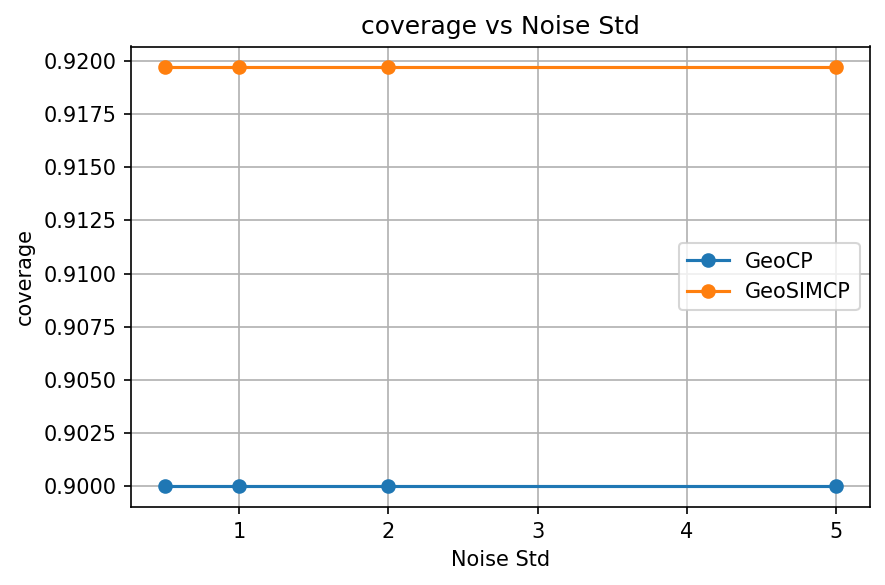

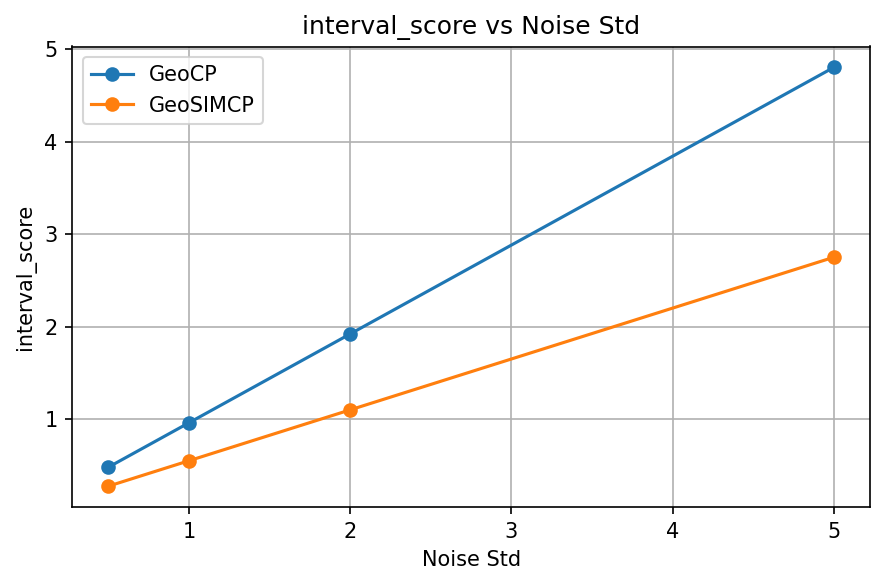

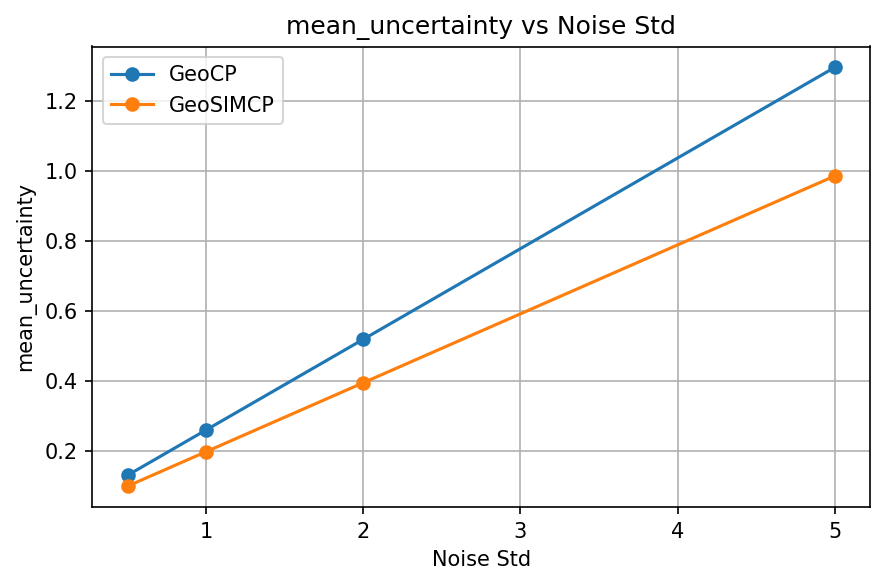

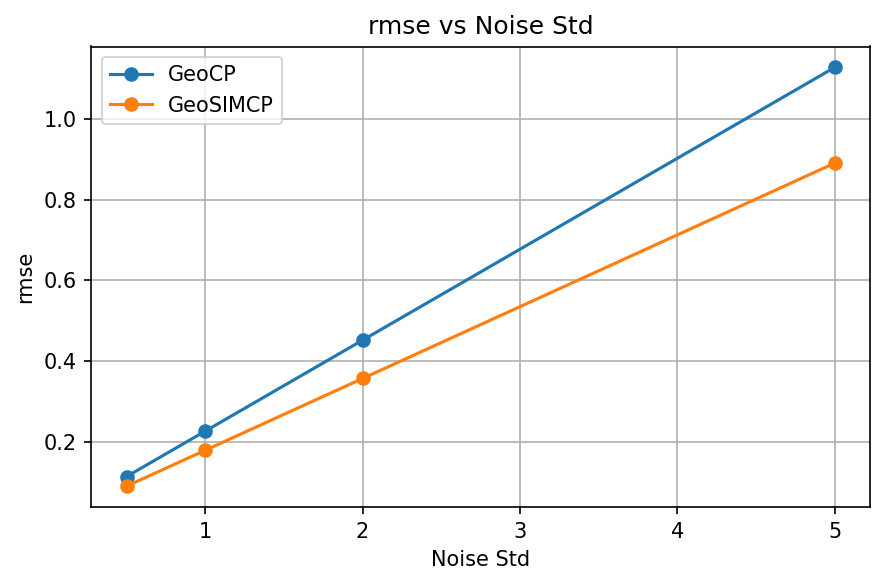

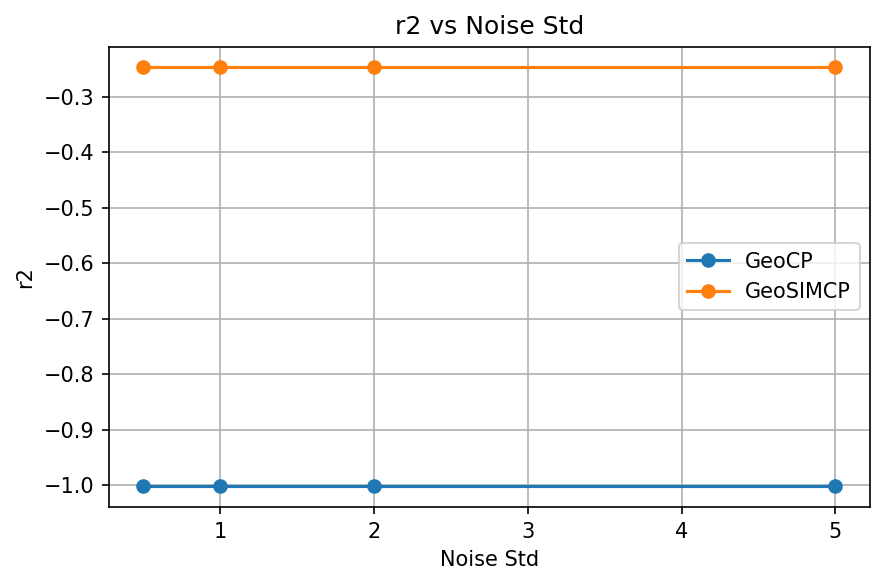

In [103]:
plot_batch_results(results_df, save_prefix="geo_cp_vs_simcp_batch", x_axis="noise_std")


STD Loop:   0%|          | 0/4 [00:00<?, ?it/s]

✅ GeoCP Optimal Parameters Summary:
  Best Bandwidth   = 0.100
  Coverage         = 0.904
  Interval Score   = 0.571
  Mean Uncertainty = 0.232
  RMSE             = 0.147
  R²               = -2.064



Sigma Loop:   0%|          | 0/1 [01:21<?, ?it/s]


KeyboardInterrupt: 

# ongoing-GeoCP

In [ ]:
# 先建立一个 (坐标 ➝ X1, X2) 的查表方式：
df_coord_to_feat = X_coords.copy()
df_coord_to_feat["X1"] = X1
df_coord_to_feat["X2"] = X2

# 定义 GeoCP 的预测函数（空间坐标 ➝ X1+X2）
def geo_predict_from_coord(X_df):
    merged = pd.merge(X_df, df_coord_to_feat, on=["x_coord", "y_coord"], how="left")
    return (merged["X1"] + merged["X2"]).values



In [ ]:
from GeoConformalSpatialRegression import GeoConformalSpatialRegression

geocp = GeoConformalSpatialRegression(
    predict_f=geo_predict_from_coord,
    nonconformity_score_f=None,
    miscoverage_level=0.1,
    bandwidth=1,
    coord_calib=loc_val.values,
    coord_test=loc_test.values,
    X_calib=X_spatial_val,
    y_calib=y_val,
    X_test=X_spatial_test,
    y_test=y_test
)

results = geocp.analyze()  # 假设你是这么调用它的

In [ ]:
from GeoConformalSpatialRegression import GeoConformalSpatialRegression

geocp_biased = GeoConformalSpatialRegression(
    predict_f=geo_predict_from_coord,
    nonconformity_score_f=None,
    miscoverage_level=0.1,
    bandwidth=1,
    coord_calib=loc_val.values,
    coord_test=loc_test.values,
    X_calib=X_spatial_val,
    y_calib=y_val,
    X_test=X_spatial_test,
    y_test=y_test
)

results = geocp.analyze()  # 假设你是这么调用它的

TypeError: 'GeoConformalResults' object is not subscriptable

In [ ]:
results

In [ ]:
results_geo = results_full.to_gpd()

In [ ]:
results_full.coverage_probability

np.float64(1.0)

In [ ]:
results_geo['geo_uncertainty']

,geo_uncertainty
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
9995,0.0
9996,0.0
9997,0.0
9998,0.0


#### biase model


In [ ]:
geocp_biased = GeoConformalSpatialRegression(
    predict_f=biased_model_predict,
    nonconformity_score_f=None,
    miscoverage_level=0.1,
    bandwidth=25,
    coord_calib=loc_val.values,
    coord_test=loc_test.values,
    X_calib=X_spatial_val,
    y_calib=y_val,
    X_test=X_spatial_test,
    y_test=y_test
)

results_biased = geocp_biased.analyze()

In [ ]:
results_biased.coverage_probability

np.float64(0.921)

In [ ]:
base_noise = np.random.normal(0, 0.75, size=(100, 100))


def generate_noise(sigma=0.2):
    smoothed_noise = gaussian_filter(base_noise, sigma=sigma)
    return smoothed_noise

In [ ]:
noise_sigmas = [1, 2]

for noise_sigma in noise_sigmas:
    noise = generate_noise(noise_sigma)
    geocp_spatial_biased = GeoConformalSpatialRegression(predict_f=lambda x_: biased_model_predict(x_, noise, sigma=5),
                                                         nonconformity_score_f=None, miscoverage_level=0.1, bandwidth=2,
                                                         coord_calib=loc_calib.values, coord_test=loc.values,
                                                         X_calib=X_calib, y_calib=true_y_calib, X_test=X_coords,
                                                         y_test=true_y)
    results_biased = geocp_spatial_biased.analyze()
    results_geo_biased = results_biased.to_gpd()
    geo_uncertainty = results_geo_biased.geo_uncertainty
    geo_uncertainty = geo_uncertainty.values.reshape(100, 100)
    coverage_rate = results_biased.coverage_probability
    fig, axes = plt.subplots(1, 4, dpi=300, figsize=(16, 4))
    ax1, ax2, ax3, ax4 = axes
    c1 = ax1.imshow(true_y.reshape(100, 100), cmap='coolwarm')
    cb1 = fig.colorbar(c1, ax=ax1, shrink=0.5)
    cb1.ax.tick_params(labelsize=8)
    c2 = ax2.imshow(geo_uncertainty, cmap='coolwarm')
    cb2 = fig.colorbar(c2, ax=ax2, shrink=0.5)
    cb2.ax.tick_params(labelsize=8)
    c3 = ax3.imshow(noise, cmap='coolwarm')
    cb3 = fig.colorbar(c3, ax=ax3, shrink=0.5)
    cb3.ax.tick_params(labelsize=8)
    noise_abs = np.abs(noise)
    c4 = ax4.imshow(np.abs(noise), cmap='coolwarm')
    cb4 = fig.colorbar(c4, ax=ax4, shrink=0.5)
    cb4.ax.tick_params(labelsize=8)
    noise_moran_i = compute_moran(noise)
    data_moran_i = compute_moran(true_y.reshape(100, 100))
    rmse = root_mean_squared_error(noise_abs, geo_uncertainty)
    corr = np.corrcoef(noise_abs.flatten(), geo_uncertainty.flatten())[0, 1]
    ssim = structural_similarity(noise_abs, geo_uncertainty, data_range=noise_abs.max() - noise_abs.min())
    plt.tight_layout()
    fig.suptitle(
        f'RMSE: {rmse:.4f}, corr: {corr:.4f}, ssim: {ssim:.4f}, data_moran: {data_moran_i:.4f}, noise_moran: {noise_moran_i:.4f}, coverage rate: {coverage_rate:.4f}')
   # plt.savefig(f'./noise_moran/sigma_{noise_sigma}.pdf', dpi=300)

NameError: name 'true_y_calib' is not defined

# previous GeoCP

In [ ]:
checkerboard = np.indices((grid_size, grid_size)).sum(axis=0) % 2 + 15
adjust = np.random.uniform(-5, 5, size=(100, 100))
checkerboard_re = checkerboard + gaussian_filter(adjust, sigma=2)
def true_model_neg_predict(X, sigma, k):
    adjusted_values = checkerboard + k * gaussian_filter(adjust, sigma=sigma)
    if isinstance(X, pd.DataFrame):
        X = X.values
    u = X[:, -1].astype(int)
    v = X[:, -2].astype(int)
    return adjusted_values[u, v]
def biased_model_neg_predict(X, noise, k, sigma):
    adjusted_values = checkerboard + k * gaussian_filter(adjust, sigma=sigma) + noise
    if isinstance(X, pd.DataFrame):
        X = X.values
    u = X[:, -1].astype(int)
    v = X[:, -2].astype(int)
    return adjusted_values[u, v]

def biased_model_neg_predict_re(noise, k, sigma, X):
    adjusted_values = checkerboard + k * gaussian_filter(adjust, sigma=sigma) + noise
    if isinstance(X, pd.DataFrame):
        X = X.values
    u = X[:, -1].astype(int)
    v = X[:, -2].astype(int)
    return adjusted_values[u, v]

checkerboard_noise = ((np.indices((grid_size, grid_size)).sum(axis=0) % 2) * 2 - 1) * 2


def neg_noise_generation(sigma, k):
    adjusted_values = checkerboard_noise + k * gaussian_filter(adjust, sigma=sigma)
    return adjusted_values

In [ ]:
data_moran_types = ['pos', 'neg']

postive_data_sigmas = [0.2, 0.4, 0.8, 1, 2, 3, 4, 5, 6]
negative_data_sigmas = [2, 3, 4, 5, 6, 7, 8, 9, 10]
noise_sigmas = [0, 0.3, 0.5, 0.6, 0.7, 0.8, 1, 2, 3, 4, 5, 6, 7, 8]

postive_data_sigmas = [0.2,0.4,5]
negative_data_sigmas = [2,3,7]
noise_sigmas = [0,0.3,4]
noise = generate_noise(5)
results_data_noise = []

for data_moran_type in data_moran_types:
    print(data_moran_type)
    for noise_sigma in noise_sigmas:
        noise = generate_noise(noise_sigma)
        if data_moran_type == 'pos':
            true_model_predict_ = lambda x_, s: true_model_predict(x_, sigma=s)
            biased_model_predict_ = lambda x_, s: biased_model_predict(x_, noise, sigma=s)
            data_sigmas = postive_data_sigmas
        elif data_moran_type == 'neg':
            true_model_predict_ = lambda x_, s: true_model_neg_predict(x_, sigma=s, k=1)
            biased_model_predict_ = lambda x_, s: biased_model_neg_predict(x_, noise, sigma=s, k=1)
            data_sigmas = negative_data_sigmas
        for data_sigma in data_sigmas:
            true_y = true_model_predict_(X_coords, data_sigma)
            X_train, X_temp, true_y_train, true_y_temp, biased_y_train, biased_y_temp, loc_train, loc_temp = train_test_split(
                X_coords, true_y, biased_y, loc, train_size=0.8)
            X_calib, X_test, true_y_calib, true_y_test, biased_y_calib, biased_y_test, loc_calib, loc_test = train_test_split(
                X_temp, true_y_temp, biased_y_temp, loc_temp, train_size=0.5)
            geocp_spatial_biased = GeoConformalSpatialRegression(
                predict_f=lambda x_: biased_model_predict_(x_, data_sigma), nonconformity_score_f=None,
                miscoverage_level=0.1, bandwidth=3, coord_calib=loc_calib.values, coord_test=loc.values,
                X_calib=X_calib, y_calib=true_y_calib, X_test=X_coords, y_test=true_y)
            results_biased = geocp_spatial_biased.analyze()
            results_geo_biased = results_biased.to_gpd()
            geo_uncertainty = results_geo_biased.geo_uncertainty
            geo_uncertainty = geo_uncertainty.values.reshape(100, 100)
            coverage_rate = results_biased.coverage_probability
            fig, axes = plt.subplots(1, 4, dpi=300, figsize=(16, 4))
            ax1, ax2, ax3, ax4 = axes
            ax1.grid(False)
            ax2.grid(False)
            ax3.grid(False)
            ax4.grid(False)
            c1 = ax1.imshow(true_y.reshape(100, 100), cmap='coolwarm')
            ax1.set_xticklabels([])
            ax1.set_yticklabels([])
            cb1 = fig.colorbar(c1, ax=ax1, shrink=0.5)
            cb1.ax.tick_params(labelsize=8)
            c2 = ax2.imshow(geo_uncertainty, cmap='coolwarm')
            ax2.set_xticklabels([])
            ax2.set_yticklabels([])
            cb2 = fig.colorbar(c2, ax=ax2, shrink=0.5)
            cb2.ax.tick_params(labelsize=8)
            c3 = ax3.imshow(noise, cmap='coolwarm')
            ax3.set_xticklabels([])
            ax3.set_yticklabels([])
            cb3 = fig.colorbar(c3, ax=ax3, shrink=0.5)
            cb3.ax.tick_params(labelsize=8)
            noise_abs = np.abs(noise)
            c4 = ax4.imshow(np.abs(noise), cmap='coolwarm')
            ax4.set_xticklabels([])
            ax4.set_yticklabels([])
            cb4 = fig.colorbar(c4, ax=ax4, shrink=0.5)
            cb4.ax.tick_params(labelsize=8)
            noise_moran_i = compute_moran(noise)
            data_moran_i = compute_moran(true_y.reshape(100, 100))
            rmse = root_mean_squared_error(noise_abs, geo_uncertainty)
            norm_noise_abs = (noise_abs - noise_abs.mean()) / noise_abs.std()
            norm_geo_uncertainty = (geo_uncertainty - geo_uncertainty.mean()) / noise_abs.std()
            nrmse = root_mean_squared_error(norm_noise_abs, norm_geo_uncertainty)
            mape = mean_absolute_percentage_error(noise_abs, geo_uncertainty)
            norm_rmse = rmse / (noise_abs.max() - noise_abs.min())
            corr = np.corrcoef(noise_abs.flatten(), geo_uncertainty.flatten())[0, 1]
            ssim = structural_similarity(noise_abs, geo_uncertainty, data_range=noise_abs.max() - noise_abs.min())
            plt.tight_layout()
            fig.suptitle(
                f'RMSE: {rmse:.4f}, NRMSE: {nrmse:.4f}, corr: {corr:.4f}, ssim: {ssim:.4f}, data_moran: {data_moran_i:.4f}, noise_moran: {noise_moran_i:.4f}, coverage rate: {coverage_rate:.4f}')
            results_data_noise.append(
                [data_moran_type, noise_moran_i, data_moran_i, rmse, corr, ssim, coverage_rate, mape, nrmse])
           # plt.savefig(
            #    f'./data_noise_results_std/{data_moran_type}_noise_sigma_{noise_sigma}_data_moran_{data_sigma}.pdf',
           #     dpi=300)
            plt.close()

pos
neg


Text(91.25, 0.5, '')

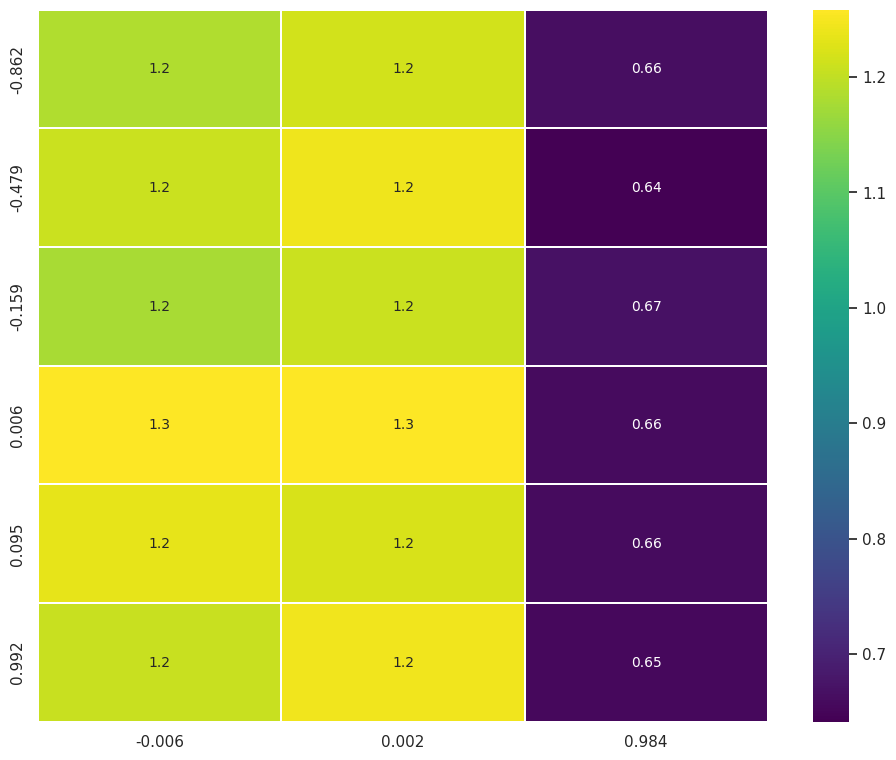

In [ ]:
import seaborn as sns
results_data_noise = np.array(results_data_noise)
results_data_noise_df = pd.DataFrame(results_data_noise,
                                     columns=['data_moran_type', 'noise_moran', 'data_moran', 'rmse', 'corr', 'ssim',
                                              'coverage_rate', 'mape', 'nrmse'])
results_data_noise_df = results_data_noise_df.astype(
    {'data_moran_type': str, 'noise_moran': float, 'data_moran': float, 'rmse': float, 'nrmse': float, 'mape': float,
     'corr': float, 'ssim': float, 'coverage_rate': float})
results_data_noise_df['noise_moran_'] = results_data_noise_df['noise_moran'].round(3)
results_data_noise_df['data_moran_'] = results_data_noise_df['data_moran'].round(3)
sns.set_theme(style='whitegrid', font='DejaVu Sans')

f, ax = plt.subplots(figsize=(10, 8))

nrmse_heatmap_data = results_data_noise_df.pivot(values='nrmse', columns='noise_moran_', index='data_moran_')

sns.heatmap(nrmse_heatmap_data, annot=True, cmap='viridis', linewidths=0.2, annot_kws={'fontsize': 10}, ax=ax)

plt.tight_layout()
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

#plt.savefig('./data_noise_results_std/results_nrmse_heatmap.pdf', dpi=300, bbox_inches='tight')

Text(91.25, 0.5, '')

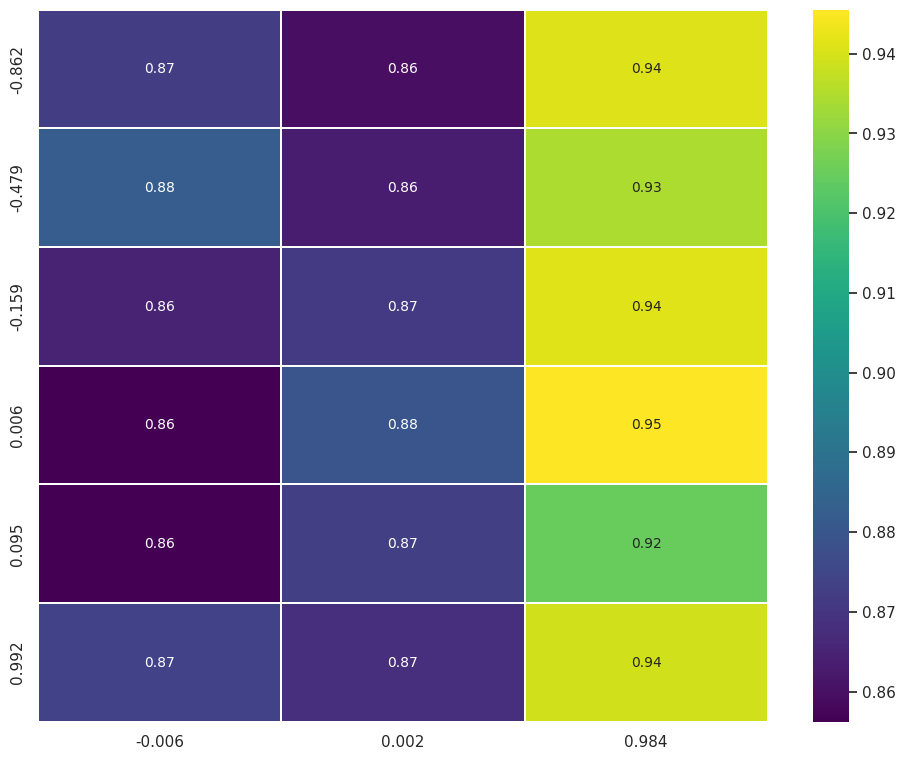

In [ ]:
sns.set_theme(style='whitegrid', font='DejaVu Sans')

plt.rcParams['font.family'] = 'Dejavu Sans'

f, ax = plt.subplots(figsize=(10, 8))

cover_heatmap_data = results_data_noise_df.pivot(values='coverage_rate', columns='noise_moran_', index='data_moran_')

sns.heatmap(cover_heatmap_data, annot=True, cmap='viridis', linewidths=0.2, annot_kws={'fontsize': 10}, ax=ax,
            vmax=results_data_noise_df['coverage_rate'].max(), vmin=results_data_noise_df['coverage_rate'].min())

plt.tight_layout()

ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')
#plt.savefig('./data_noise_results_std/results_cover_heatmap.pdf', dpi=300, bbox_inches='tight')

Text(82.0, 0.5, '')

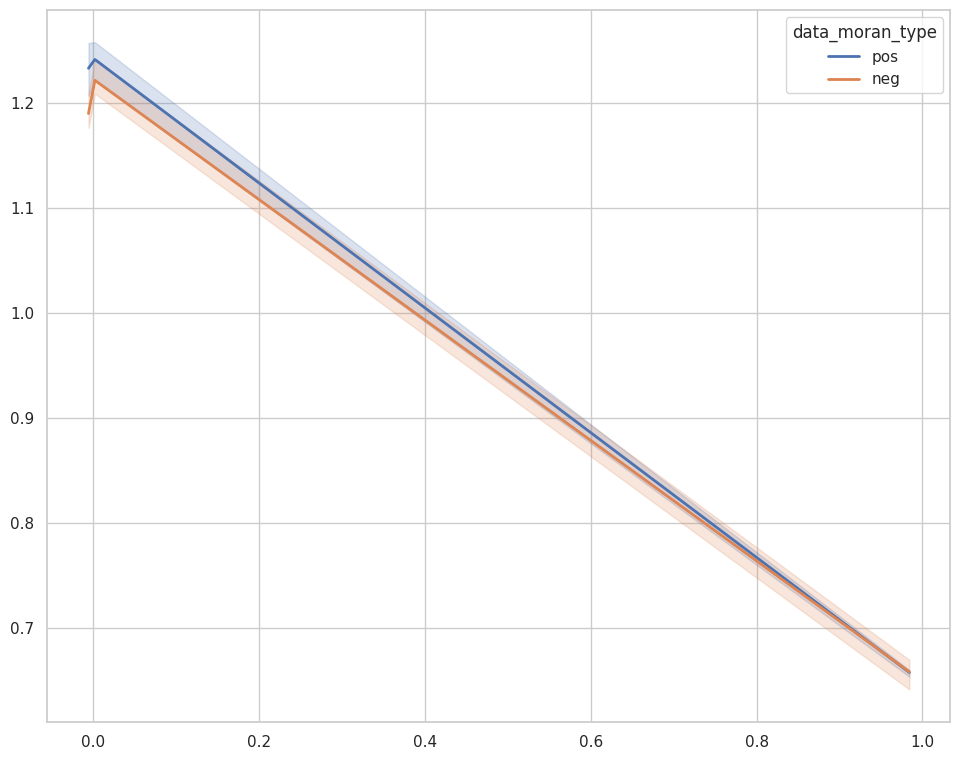

In [ ]:
sns.set_theme(style='whitegrid', font='DejaVu Sans')

plt.rcParams['font.family'] = 'Dejavu Sans'

f, ax = plt.subplots(figsize=(10, 8))

sns.lineplot(results_data_noise_df, x='noise_moran', y='nrmse', hue='data_moran_type', ax=ax, lw=2)

plt.tight_layout()

ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

#plt.savefig('./data_noise_results_std/summary_nrmse_lineplot.pdf', dpi=300, bbox_inches='tight')

Text(72.375, 0.5, '')

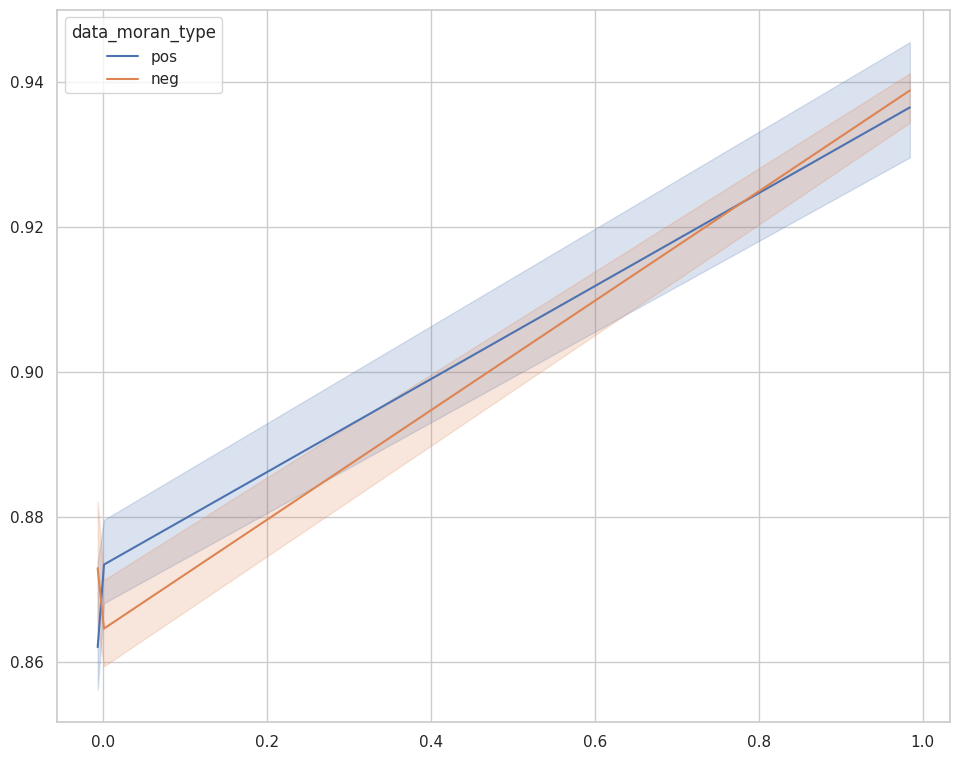

In [ ]:
sns.set_theme(style='whitegrid', font='DejaVu Sans')

plt.rcParams['font.family'] = 'Dejavu Sans'

f, ax = plt.subplots(figsize=(10, 8))

sns.lineplot(results_data_noise_df, x='noise_moran', y='coverage_rate', hue='data_moran_type', ax=ax)

plt.tight_layout()

ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

#plt.savefig('./data_noise_results_std/summary_cover_lineplot.pdf', dpi=300, bbox_inches='tight')

# GeoCP with optimiztion


## Function

In [ ]:
# Modified GeoCP Bandwidth Sweep with Compatibility Fixes (e.g., sklearn RMSE)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score


def interval_score(y_true, lower, upper, alpha=0.1, epsilon=1e-6):
    width = np.maximum(upper - lower, epsilon)
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    score = width + (2 / alpha) * (below + above)
    return np.where(np.isnan(score), 0.0, score)


def bandwidth_grid_sweep_geocp(
    bandwidth_list,
    model_spatial,
    X_val,
    X_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    noise_abs=None,
    alpha=0.1,
    coverage_threshold=0.9
):
    coverage_list = []
    uncertainty_list = []
    interval_score_list = []
    rmse_list = []
    r2_list = []

    for bw in bandwidth_list:
        model = GeoConformalSpatialRegression(
            predict_f=model_spatial.predict,
            miscoverage_level=alpha,
            bandwidth=bw,
            coord_calib=loc_val.values,
            coord_test=loc_test.values,
            X_calib=X_val,
            y_calib=y_val,
            X_test=X_test,
            y_test=y_test
        )

        result = model.analyze()
        coverage_list.append(result.coverage_probability)

        unc = np.array(result.geo_uncertainty)
        unc = unc[~np.isnan(unc)]
        uncertainty_list.append(np.mean(unc) if len(unc) > 0 else np.nan)

        lower = np.array(result.lower_bound)
        upper = np.array(result.upper_bound)
        y_true = np.array(y_test)

        score = interval_score(y_true, lower, upper, alpha=alpha)
        interval_score_list.append(np.mean(score))

        if noise_abs is not None:
            geo_uncertainty = result.geo_uncertainty.reshape(noise_abs.shape)
            rmse = np.sqrt(mean_squared_error(noise_abs.flatten(), geo_uncertainty.flatten()))
            rmse_list.append(rmse)
            r2 = r2_score(noise_abs.flatten(), geo_uncertainty.flatten())
            r2_list.append(r2)
        else:
            rmse_list.append(np.nan)
            r2_list.append(np.nan)

    mask = np.array(coverage_list) >= coverage_threshold
    masked_score = np.where(mask, interval_score_list, np.inf)
    best_idx = np.argmin(masked_score)
    best_bw = bandwidth_list[best_idx]

    print(f"Best Bandwidth (Coverage ≥ {coverage_threshold}):")
    print(f"  Bandwidth       = {best_bw:.3f}")
    print(f"  Coverage        = {coverage_list[best_idx]:.3f}")
    print(f"  Interval Score  = {interval_score_list[best_idx]:.3f}")
    print(f"  Mean Interval   = {uncertainty_list[best_idx]:.3f}")
    print(f"  RMSE (noise)    = {rmse_list[best_idx]:.3f}")
    print(f"  R2 (noise)      = {r2_list[best_idx]:.3f}")

    return {
        'coverage': coverage_list[best_idx],
        'interval_score': interval_score_list[best_idx],
        'mean_uncertainty': uncertainty_list[best_idx],
        'rmse': rmse_list[best_idx],
        'r2': r2_list[best_idx],
        'nrmse': rmse_list[best_idx] / (noise_abs.max() - noise_abs.min()) if noise_abs is not None else np.nan,
        'best_bandwidth': best_bw
    }

## Run GeoCP

In [ ]:
# GeoCP 模拟实验主循环（嵌入最优 bandwidth 搜索 + 多指标输出）

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

results_data_noise = []
data_moran_types = ['pos', 'neg']
postive_data_sigmas = [0.2]
negative_data_sigmas = [2]
noise_sigmas = [0]

for data_moran_type in data_moran_types:
    for noise_sigma in noise_sigmas:
        noise = generate_noise(noise_sigma)

        if data_moran_type == 'pos':
            true_model_predict_ = lambda x_, s: true_model_predict(x_, sigma=s)
            biased_model_predict_ = lambda x_, s: biased_model_predict(x_, noise, sigma=s)
            data_sigmas = postive_data_sigmas
        else:
            true_model_predict_ = lambda x_, s: true_model_neg_predict(x_, sigma=s, k=1)
            biased_model_predict_ = lambda x_, s: biased_model_neg_predict(x_, noise, sigma=s, k=1)
            data_sigmas = negative_data_sigmas

        for data_sigma in data_sigmas:
            true_y = true_model_predict_(X_coords, data_sigma)
            biased_y = biased_model_predict_(X_coords, data_sigma)
            loc = X_coords

            X_train, X_temp, true_y_train, true_y_temp, biased_y_train, biased_y_temp, loc_train, loc_temp = train_test_split(
                X_coords, true_y, biased_y, loc, train_size=0.8)
            X_calib, X_test, true_y_calib, true_y_test, biased_y_calib, biased_y_test, loc_calib, loc_test = train_test_split(
                X_temp, true_y_temp, biased_y_temp, loc_temp, train_size=0.5)

            noise_abs = np.abs(noise)

            model_spatial = type("Dummy", (), {"predict": lambda self, x: biased_model_predict_(x, data_sigma)})()

            metrics = bandwidth_grid_sweep_geocp(
                bandwidth_list=np.linspace(0.1, 3.0, 15),
                model_spatial=model_spatial,
                X_val=X_calib,
                X_test=X_coords,
                y_val=true_y_calib,
                y_test=true_y,
                loc_val=loc_calib,
                loc_test=loc,
                noise_abs=noise_abs,
                alpha=0.1,
                coverage_threshold=0.9
            )

            results_data_noise.append([
                data_moran_type,
                compute_moran(noise),
                compute_moran(true_y.reshape(100, 100)),
                metrics['rmse'],
                metrics['r2'],
                metrics['coverage'],
                metrics['interval_score'],
                metrics['mean_uncertainty'],
                metrics['nrmse']
            ])


Best Bandwidth (Coverage ≥ 0.9):
  Bandwidth       = 0.100
  Coverage        = 0.584
  Interval Score  = 5.384
  Mean Interval   = 0.637
  RMSE (noise)    = 0.608
  R2 (noise)      = -0.824


/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity/GeoConformal/GeoConformalSpatialRegression.py:131: RuntimeWarning: invalid value encountered in divide
  normalized_cumsum_weights = cumsum_weights / cumsum_weights[-1]


Best Bandwidth (Coverage ≥ 0.9):
  Bandwidth       = 0.100
  Coverage        = 0.584
  Interval Score  = 5.343
  Mean Interval   = 0.648
  RMSE (noise)    = 0.618
  R2 (noise)      = -0.881


/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity/GeoConformal/GeoConformalSpatialRegression.py:131: RuntimeWarning: invalid value encountered in divide
  normalized_cumsum_weights = cumsum_weights / cumsum_weights[-1]


Best Bandwidth (Coverage ≥ 0.9):
  Bandwidth       = 0.100
  Coverage        = 0.556
  Interval Score  = 5.554
  Mean Interval   = 0.616
  RMSE (noise)    = 0.613
  R2 (noise)      = -0.852


...

Best Bandwidth (Coverage ≥ 0.9):
  Bandwidth       = 1.964
  Coverage        = 0.909
  Interval Score  = 0.151
  Mean Interval   = 0.069
  RMSE (noise)    = 0.030
  R2 (noise)      = 0.266


/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity/GeoConformal/GeoConformalSpatialRegression.py:131: RuntimeWarning: invalid value encountered in divide
  normalized_cumsum_weights = cumsum_weights / cumsum_weights[-1]


Best Bandwidth (Coverage ≥ 0.9):
  Bandwidth       = 1.964
  Coverage        = 0.909
  Interval Score  = 0.148
  Mean Interval   = 0.068
  RMSE (noise)    = 0.028
  R2 (noise)      = 0.337


/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity/GeoConformal/GeoConformalSpatialRegression.py:131: RuntimeWarning: invalid value encountered in divide
  normalized_cumsum_weights = cumsum_weights / cumsum_weights[-1]


Best Bandwidth (Coverage ≥ 0.9):
  Bandwidth       = 2.379
  Coverage        = 0.909
  Interval Score  = 0.157
  Mean Interval   = 0.071
  RMSE (noise)    = 0.032
  R2 (noise)      = 0.146


## Visulization

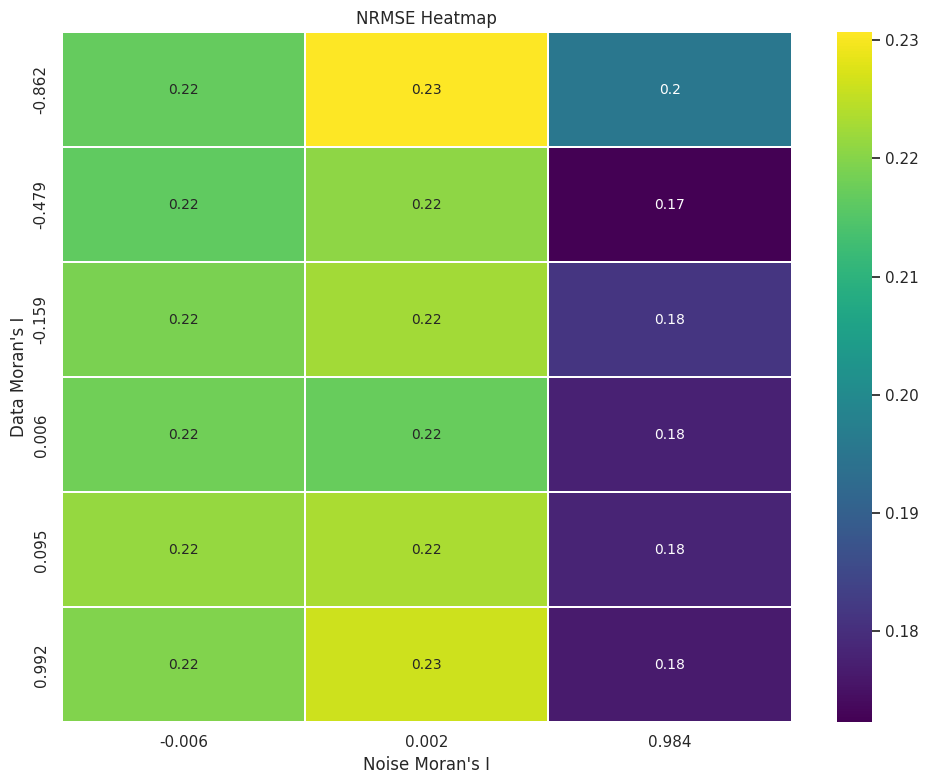

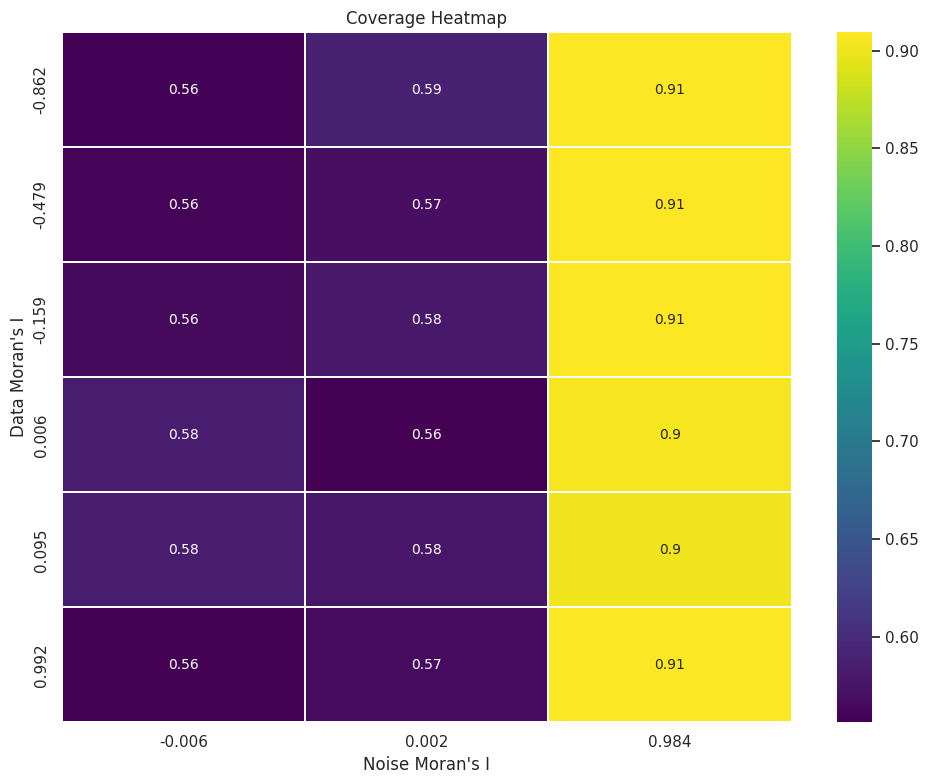

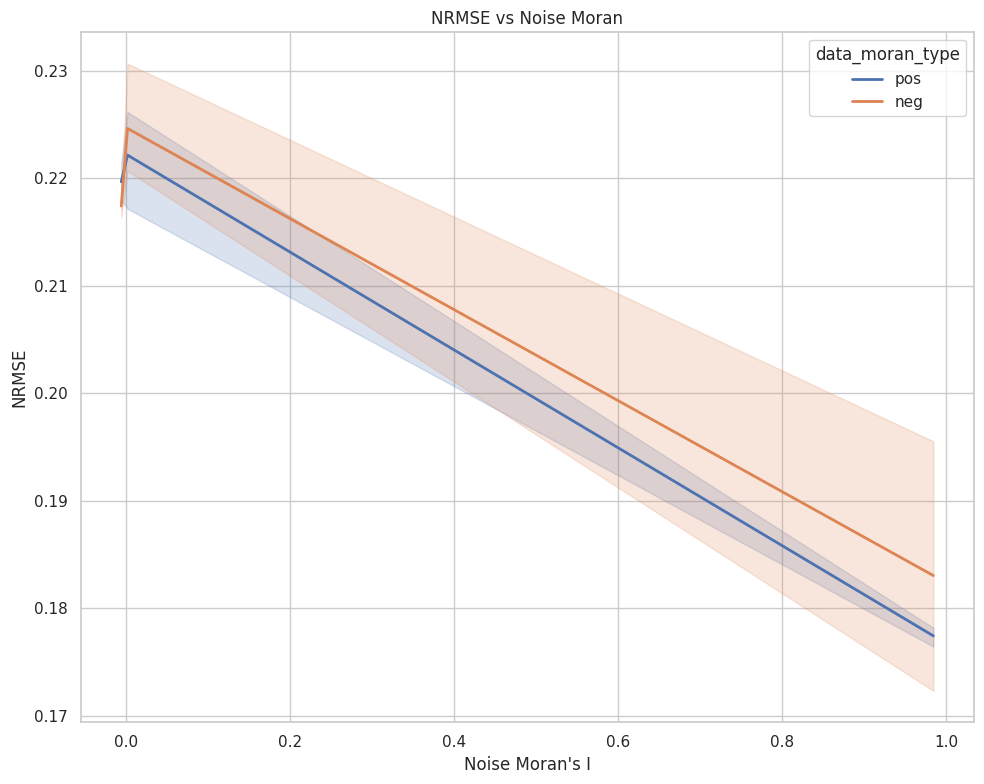

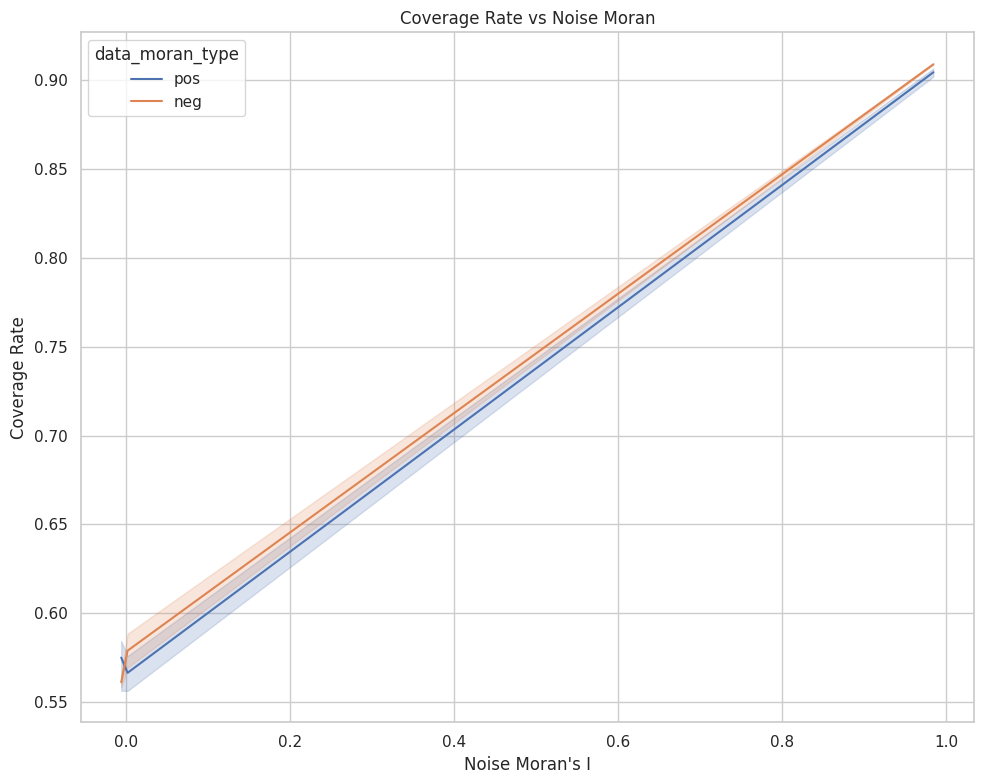

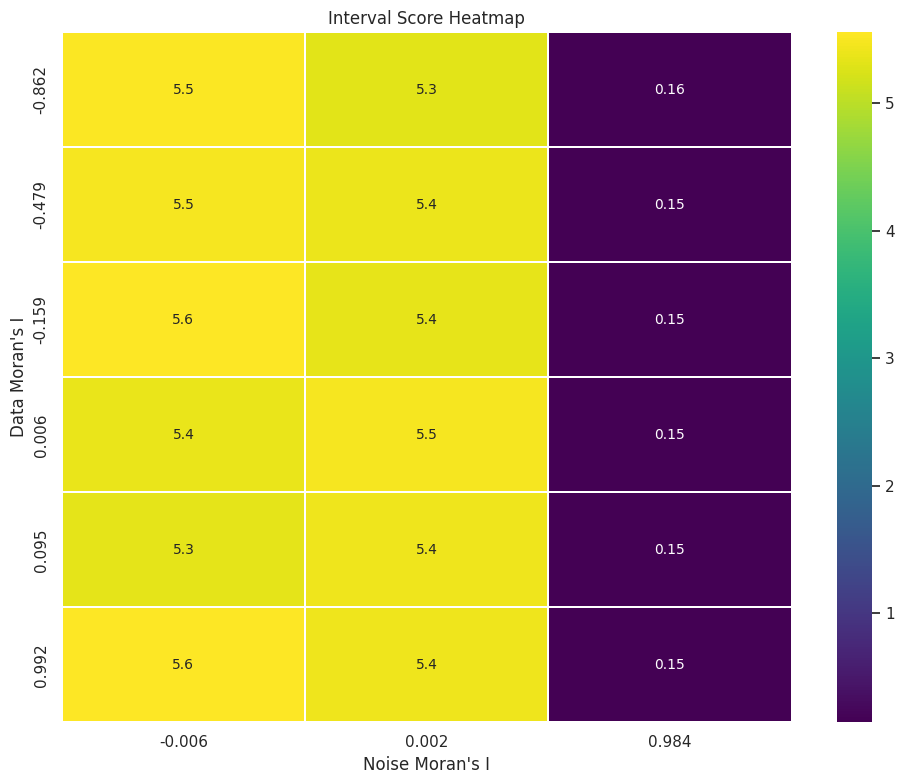

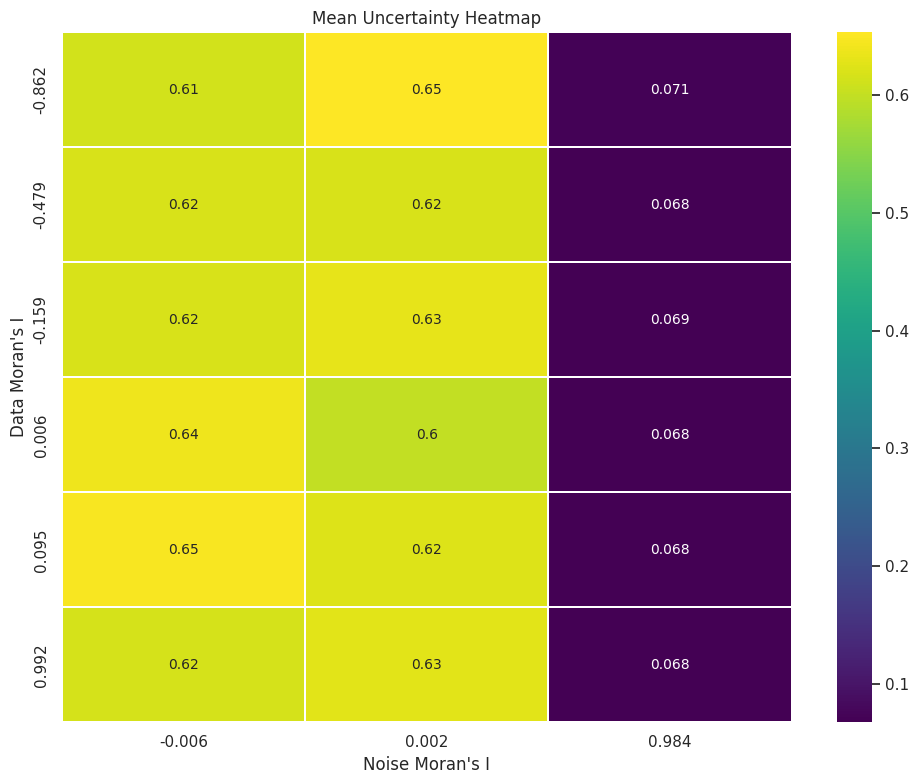

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 🟦 请将你的 results_data_noise 替换到下面
# results_data_noise = np.array(...)  # 👈 请替换为你的数据

# ✅ 构建 DataFrame
results_data_noise_df = pd.DataFrame(
    results_data_noise,
    columns=[
        'data_moran_type', 'noise_moran', 'data_moran',
        'rmse', 'r2', 'coverage_rate', 'interval_score',
        'mean_uncertainty', 'nrmse'
    ]
)

# 类型转换 & 格式化
results_data_noise_df = results_data_noise_df.astype({
    'data_moran_type': str, 'noise_moran': float, 'data_moran': float,
    'rmse': float, 'r2': float, 'coverage_rate': float,
    'interval_score': float, 'mean_uncertainty': float, 'nrmse': float
})
results_data_noise_df['noise_moran_'] = results_data_noise_df['noise_moran'].round(3)
results_data_noise_df['data_moran_'] = results_data_noise_df['data_moran'].round(3)

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1️⃣ Heatmap of NRMSE
f1, ax1 = plt.subplots(figsize=(10, 8))
nrmse_heatmap_data = results_data_noise_df.pivot_table(
    values='nrmse', columns='noise_moran_', index='data_moran_', aggfunc='mean')
sns.heatmap(nrmse_heatmap_data, annot=True, cmap='viridis', linewidths=0.2,
            annot_kws={'fontsize': 10}, ax=ax1)
ax1.set_title('NRMSE Heatmap')
ax1.set_xlabel("Noise Moran's I")
ax1.set_ylabel("Data Moran's I")
plt.tight_layout()

# 2️⃣ Heatmap of Coverage
f2, ax2 = plt.subplots(figsize=(10, 8))
coverage_heatmap_data = results_data_noise_df.pivot_table(
    values='coverage_rate', columns='noise_moran_', index='data_moran_', aggfunc='mean')
sns.heatmap(coverage_heatmap_data, annot=True, cmap='viridis', linewidths=0.2,
            annot_kws={'fontsize': 10}, ax=ax2,
            vmax=results_data_noise_df['coverage_rate'].max(),
            vmin=results_data_noise_df['coverage_rate'].min())
ax2.set_title('Coverage Heatmap')
ax2.set_xlabel("Noise Moran's I")
ax2.set_ylabel("Data Moran's I")
plt.tight_layout()

# 3️⃣ Lineplot of NRMSE vs Noise Moran
f3, ax3 = plt.subplots(figsize=(10, 8))
sns.lineplot(data=results_data_noise_df, x='noise_moran', y='nrmse',
             hue='data_moran_type', ax=ax3, lw=2)
ax3.set_title('NRMSE vs Noise Moran')
ax3.set_xlabel("Noise Moran's I")
ax3.set_ylabel("NRMSE")
plt.tight_layout()

# 4️⃣ Lineplot of Coverage vs Noise Moran
f4, ax4 = plt.subplots(figsize=(10, 8))
sns.lineplot(data=results_data_noise_df, x='noise_moran', y='coverage_rate',
             hue='data_moran_type', ax=ax4)
ax4.set_title('Coverage Rate vs Noise Moran')
ax4.set_xlabel("Noise Moran's I")
ax4.set_ylabel("Coverage Rate")
plt.tight_layout()
# 5️⃣ Heatmap of Interval Score
f5, ax5 = plt.subplots(figsize=(10, 8))
interval_score_heatmap_data = results_data_noise_df.pivot_table(
    values='interval_score', columns='noise_moran_', index='data_moran_', aggfunc='mean')
sns.heatmap(interval_score_heatmap_data, annot=True, cmap='viridis', linewidths=0.2,
            annot_kws={'fontsize': 10}, ax=ax5)
ax5.set_title('Interval Score Heatmap')
ax5.set_xlabel("Noise Moran's I")
ax5.set_ylabel("Data Moran's I")
plt.tight_layout()

# 6️⃣ Heatmap of Mean Uncertainty
f6, ax6 = plt.subplots(figsize=(10, 8))
uncertainty_heatmap_data = results_data_noise_df.pivot_table(
    values='mean_uncertainty', columns='noise_moran_', index='data_moran_', aggfunc='mean')
sns.heatmap(uncertainty_heatmap_data, annot=True, cmap='viridis', linewidths=0.2,
            annot_kws={'fontsize': 10}, ax=ax6)
ax6.set_title('Mean Uncertainty Heatmap')
ax6.set_xlabel("Noise Moran's I")
ax6.set_ylabel("Data Moran's I")
plt.tight_layout()


# GeoSIMCP

## Function

In [ ]:
from GeoSIMCP_non_zero import GeoSIMConformalSpatialRegression
#from GeoSIMCP import GeoSIMConformalSpatialRegression


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

def interval_score(y_true, lower, upper, alpha=0.1):
    width = upper - lower
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    return width + (2 / alpha) * (below + above)

def select_best_lambda_bandwidth(coverage_grid, score_grid, lambda_list, bandwidth_list, threshold=0.9):
    mask = coverage_grid >= threshold
    masked_score = np.where(mask, score_grid, np.inf)
    idx = np.unravel_index(np.argmin(masked_score), masked_score.shape)
    best_lambda = lambda_list[idx[1]]
    best_bandwidth = bandwidth_list[idx[0]]
    return best_lambda, best_bandwidth, masked_score[idx], idx

def geosimcp_bandwidth_lambda_grid_sweep(
    bandwidth_list,
    lambda_list,
    model_spatial,
    X_spatial_val,
    X_spatial_test,
    X_aspatial_val,
    X_aspatial_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    noise_abs=None,
    alpha=0.1,
    coverage_threshold=0.9
):

    print("🧪 Checking for NaNs before model init...")

    checks = {
        "X_spatial_val": X_spatial_val,
        "X_spatial_test": X_spatial_test,
        "X_aspatial_val": X_aspatial_val,
        "X_aspatial_test": X_aspatial_test,
        "y_val": y_val,
        "y_test": y_test,
        "loc_val": loc_val,
        "loc_test": loc_test
    }

    for name, array in checks.items():
        if hasattr(array, "isnull"):
            nan_check = array.isnull().sum()
        else:
            nan_check = np.isnan(array).sum()
        print(f"{name}: {nan_check} NaNs")

    coverage_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    uncertainty_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    interval_score_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    rmse_grid = np.full_like(interval_score_grid, np.nan)
    r2_grid = np.full_like(interval_score_grid, np.nan)

    for i, bw in enumerate(bandwidth_list):
        for j, lam in enumerate(lambda_list):
            try:
                model = GeoSIMConformalSpatialRegression(
                    predict_f=model_spatial.predict,
                    miscoverage_level=alpha,
                    bandwidth=bw,
                    coord_calib=loc_val.values,
                    coord_test=loc_test.values,
                    X_calib=X_spatial_val,
                    y_calib=y_val,
                    X_test=X_spatial_test,
                    y_test=y_test,
                    X_calib_weight=X_aspatial_val,
                    X_test_weight=X_aspatial_test,
                    lambda_weight=lam
                )
                result = model.analyze()

                coverage_grid[i, j] = result.coverage_probability
                uncertainty_grid[i, j] = result.uncertainty

                lower = np.array(result.lower_bound)
                upper = np.array(result.upper_bound)
                y_true = np.array(y_test)

                score = interval_score(y_true, lower, upper, alpha=alpha)
                interval_score_grid[i, j] = np.mean(score)

                if noise_abs is not None:
                    geo_uncertainty = result.geo_uncertainty.reshape(noise_abs.shape)
                    rmse_grid[i, j] = np.sqrt(mean_squared_error(noise_abs.flatten(), geo_uncertainty.flatten()))
                    r2_grid[i, j] = r2_score(noise_abs.flatten(), geo_uncertainty.flatten())

            except Exception as e:
                print(f"❌ Model failed at bandwidth={bw}, lambda={lam}")
                print(f"   Error: {str(e)}")
                continue

    best_lambda, best_bw, best_score, idx = select_best_lambda_bandwidth(
        coverage_grid, interval_score_grid, lambda_list, bandwidth_list, threshold=coverage_threshold
    )
    best_coverage = coverage_grid[idx]
    best_uncertainty = uncertainty_grid[idx]

    print("\n✅ GeoSIMCP Optimal Parameters Summary:")
    print(f"  Best Bandwidth  = {best_bw:.3f}")
    print(f"  Best Lambda     = {best_lambda:.3f}")
    print(f"  Coverage        = {best_coverage:.3f}")
    print(f"  Interval Score  = {best_score:.3f}")
    print(f"  Mean Uncertainty= {best_uncertainty:.3f}")
    if noise_abs is not None:
        print(f"  RMSE            = {rmse_grid[idx]:.3f}")
        print(f"  R2              = {r2_grid[idx]:.3f}")

    return {
        'coverage': best_coverage,
        'interval_score': best_score,
        'mean_uncertainty': best_uncertainty,
        'rmse': rmse_grid[idx],
        'r2': r2_grid[idx],
        'nrmse': rmse_grid[idx] / (noise_abs.max() - noise_abs.min()) if noise_abs is not None else np.nan,
        'best_bandwidth': best_bw,
        'best_lambda': best_lambda
    }


## Run GeoSIMCP

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

results_data_noise_geoSIMCP = []

data_moran_types = ['pos', 'neg']
postive_data_sigmas = [0.2]
negative_data_sigmas = [2]
noise_sigmas = [0]

for data_moran_type in data_moran_types:
    for noise_sigma in noise_sigmas:
        noise = generate_noise(noise_sigma)

        if data_moran_type == 'pos':
            true_model_predict_ = lambda x_, s: true_model_predict(x_, sigma=s)
            biased_model_predict_ = lambda x_, s: biased_model_predict(x_, noise, sigma=s)
            data_sigmas = postive_data_sigmas
        else:
            true_model_predict_ = lambda x_, s: true_model_neg_predict(x_, sigma=s, k=1)
            biased_model_predict_ = lambda x_, s: biased_model_neg_predict(x_, noise, sigma=s, k=1)
            data_sigmas = negative_data_sigmas

        for data_sigma in data_sigmas:
            true_y = true_model_predict_(X_coords, data_sigma)
            biased_y = biased_model_predict_(X_coords, data_sigma)
            loc = X_coords
            noise_abs = np.abs(noise)

            X_train, X_temp, true_y_train, true_y_temp, biased_y_train, biased_y_temp, loc_train, loc_temp = train_test_split(
                X_coords, true_y, biased_y, loc, train_size=0.8)
            X_calib, X_test, true_y_calib, true_y_test, biased_y_calib, biased_y_test, loc_calib, loc_test = train_test_split(
                X_temp, true_y_temp, biased_y_temp, loc_temp, train_size=0.5)

            model_spatial = type("Dummy", (), {"predict": lambda self, x: biased_model_predict_(x, data_sigma)})()
            print(data_sigma)
            metrics = geosimcp_bandwidth_lambda_grid_sweep(
                bandwidth_list=np.linspace(0.2, 3.0, 15),
                lambda_list=np.linspace(0, 1.0, 10),
                model_spatial=model_spatial,
                X_spatial_val=X_calib,
                X_spatial_test=X_coords,
                X_aspatial_val=X_calib,
                X_aspatial_test=X_coords,
                y_val=true_y_calib,
                y_test=true_y,
                loc_val=loc_calib,
                loc_test=loc,
                noise_abs=noise_abs,
                alpha=0.1,
                coverage_threshold=0.9
            )

            results_data_noise_geoSIMCP.append([
                data_moran_type,
                compute_moran(noise),
                compute_moran(true_y.reshape(100, 100)),
                metrics['rmse'],
                metrics['r2'],
                metrics['coverage'],
                metrics['interval_score'],
                metrics['mean_uncertainty'],
                metrics['nrmse']
            ])


0.2
🧪 Checking for NaNs before model init...
X_spatial_val: x_coord    0
y_coord    0
dtype: int64 NaNs
X_spatial_test: x_coord    0
y_coord    0
dtype: int64 NaNs
X_aspatial_val: x_coord    0
y_coord    0
dtype: int64 NaNs
X_aspatial_test: x_coord    0
y_coord    0
dtype: int64 NaNs
y_val: 0 NaNs
y_test: 0 NaNs
loc_val: x_coord    0
y_coord    0
dtype: int64 NaNs
loc_test: x_coord    0
y_coord    0
dtype: int64 NaNs

✅ GeoSIMCP Optimal Parameters Summary:
  Best Bandwidth  = 2.800
  Best Lambda     = 0.222
  Coverage        = 0.901
  Interval Score  = 3.121
  Mean Uncertainty= 1.248
  RMSE            = 0.807
  R2              = -2.212
2
🧪 Checking for NaNs before model init...
X_spatial_val: x_coord    0
y_coord    0
dtype: int64 NaNs
X_spatial_test: x_coord    0
y_coord    0
dtype: int64 NaNs
X_aspatial_val: x_coord    0
y_coord    0
dtype: int64 NaNs
X_aspatial_test: x_coord    0
y_coord    0
dtype: int64 NaNs
y_val: 0 NaNs
y_test: 0 NaNs
loc_val: x_coord    0
y_coord    0
dtype: in

In [ ]:
print("Checking for NaNs...")
print("X_spatial_val:", np.isnan(X_calib).sum())
print("X_spatial_test:", np.isnan(X_coords).sum())
print("y_val:", np.isnan(true_y_calib).sum())
print("y_test:", np.isnan(true_y).sum())
print("X_aspatial_val:", np.isnan(X_calib).sum())
print("X_aspatial_test:", np.isnan(X_coords).sum())
print("loc_val:", np.isnan(loc_calib).sum())
print("loc_test:", np.isnan(loc).sum())
print("noise_abs:", np.isnan(noise_abs).sum())


Checking for NaNs...
X_spatial_val: x_coord    0
y_coord    0
dtype: int64
X_spatial_test: x_coord    0
y_coord    0
dtype: int64
y_val: 0
y_test: 0
X_aspatial_val: x_coord    0
y_coord    0
dtype: int64
X_aspatial_test: x_coord    0
y_coord    0
dtype: int64
loc_val: x_coord    0
y_coord    0
dtype: int64
loc_test: x_coord    0
y_coord    0
dtype: int64
noise_abs: 0


In [ ]:
print(np.isnan(X_coords).sum(), 'NaNs in X_coords')
print(np.isnan(true_y).sum(), 'NaNs in true_y')
print(np.isnan(biased_y).sum(), 'NaNs in biased_y')
print(np.isnan(noise).sum(), 'NaNs in noise')


x_coord    0
y_coord    0
dtype: int64 NaNs in X_coords
0 NaNs in true_y
0 NaNs in biased_y
0 NaNs in noise


## visulization

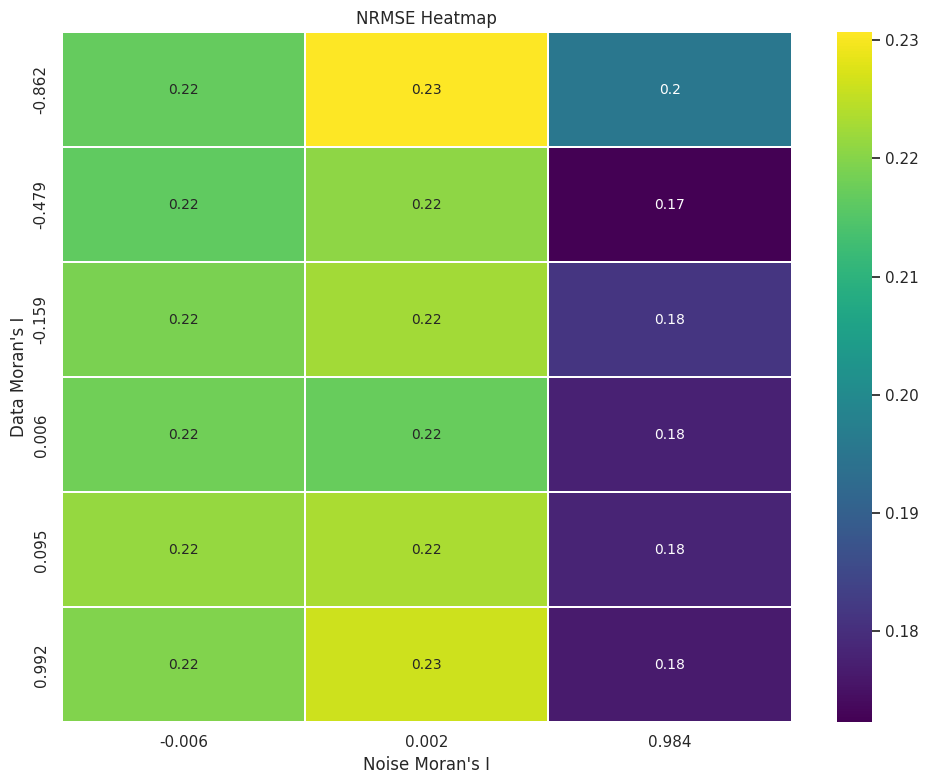

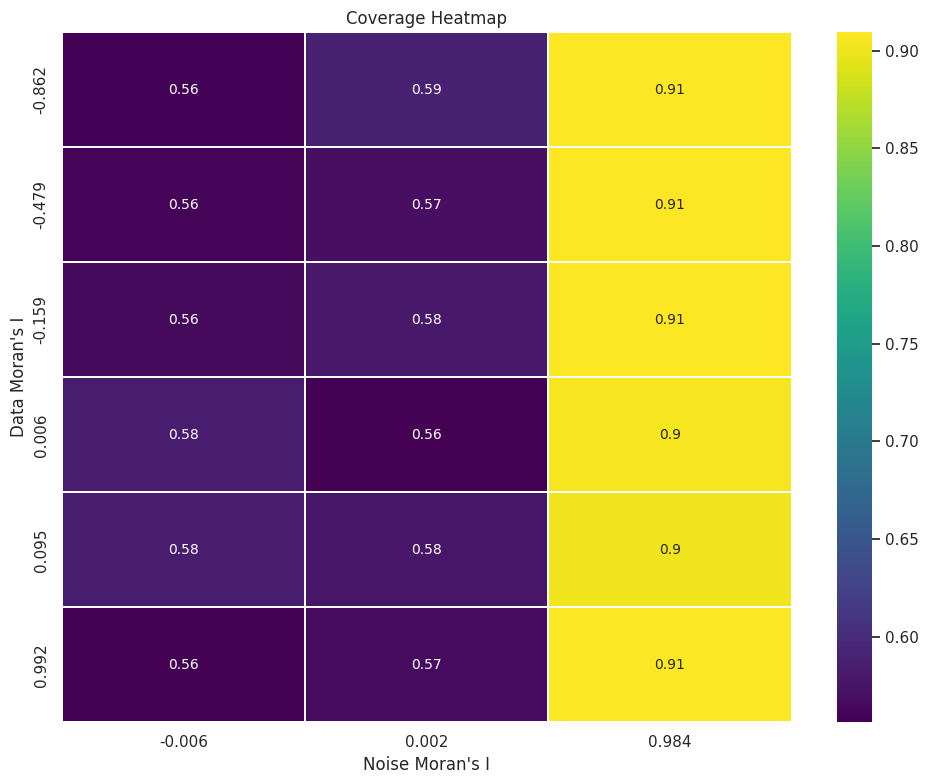

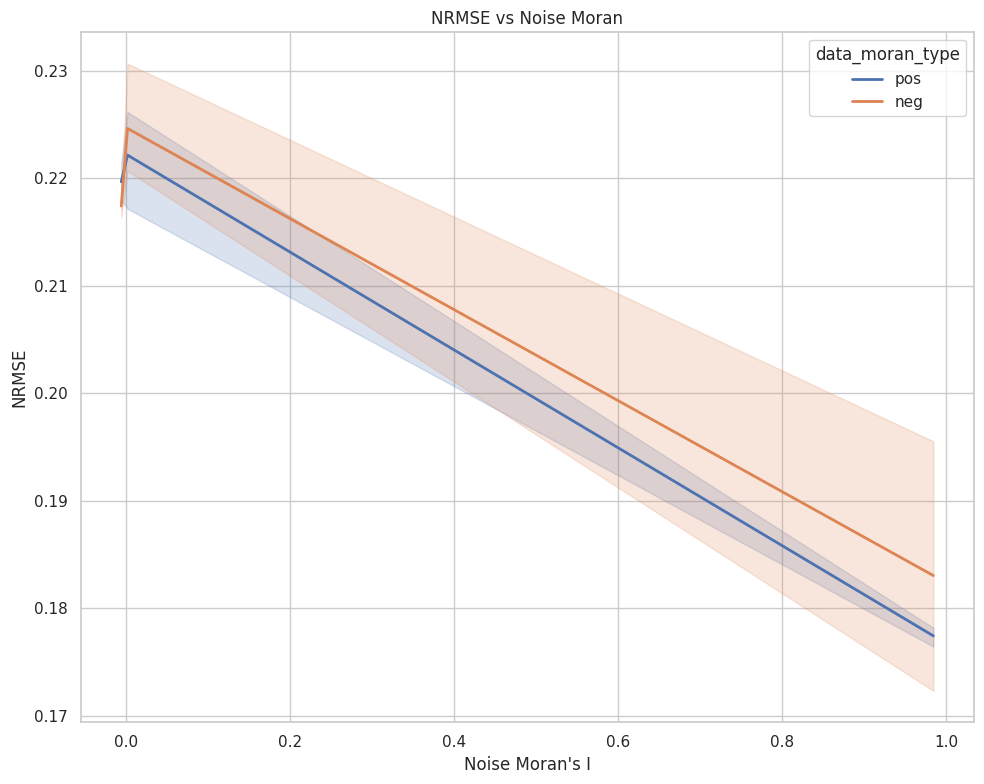

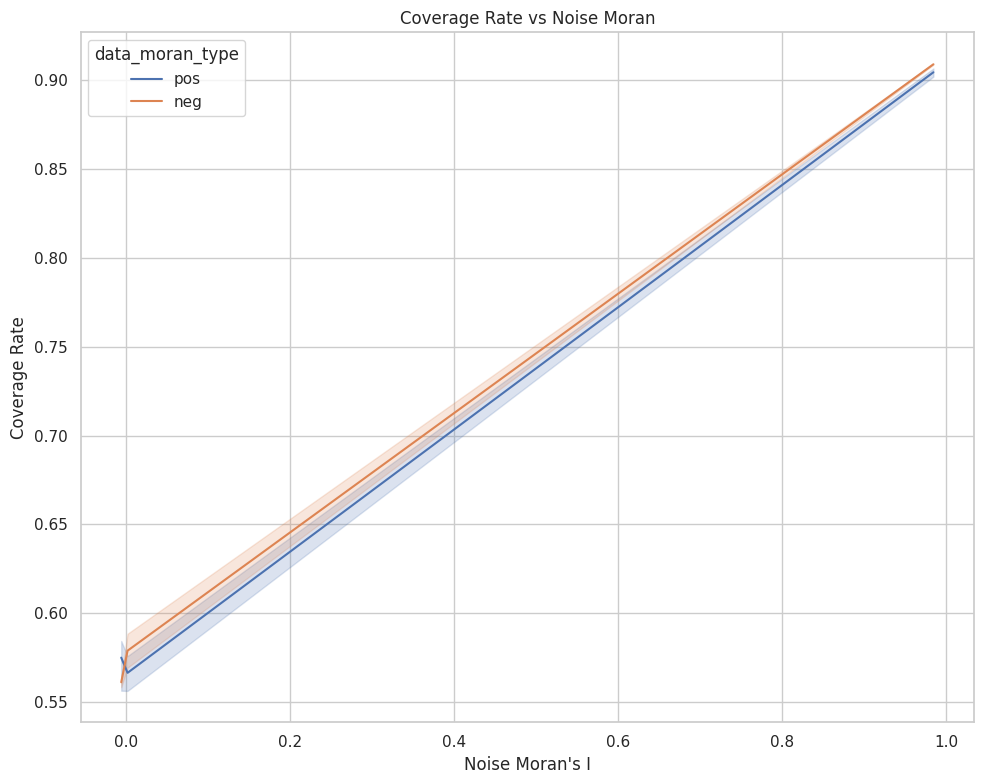

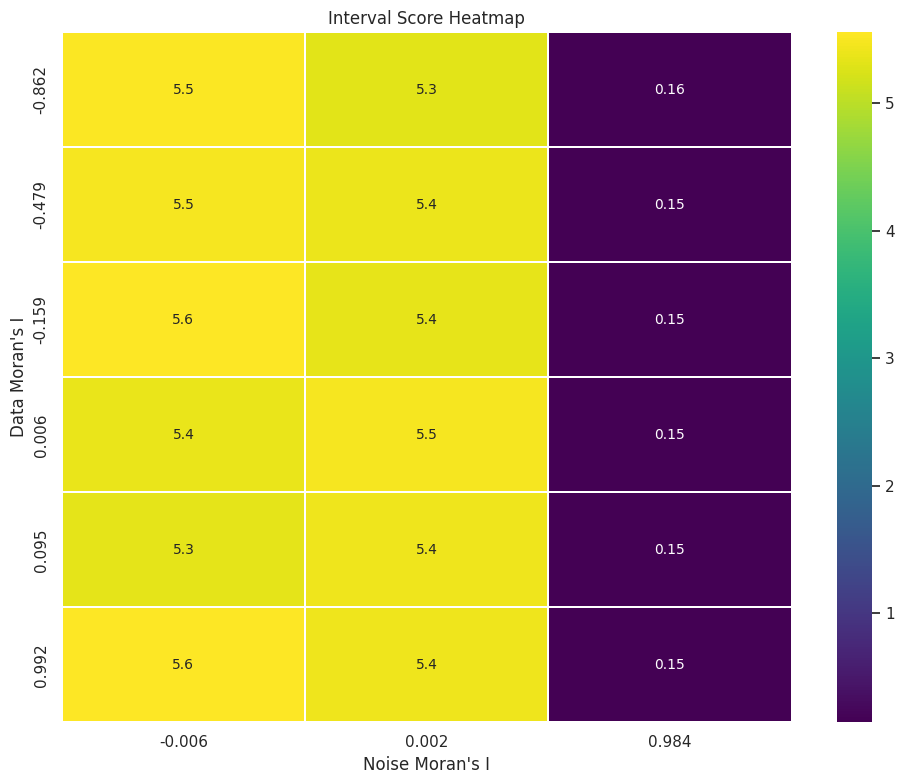

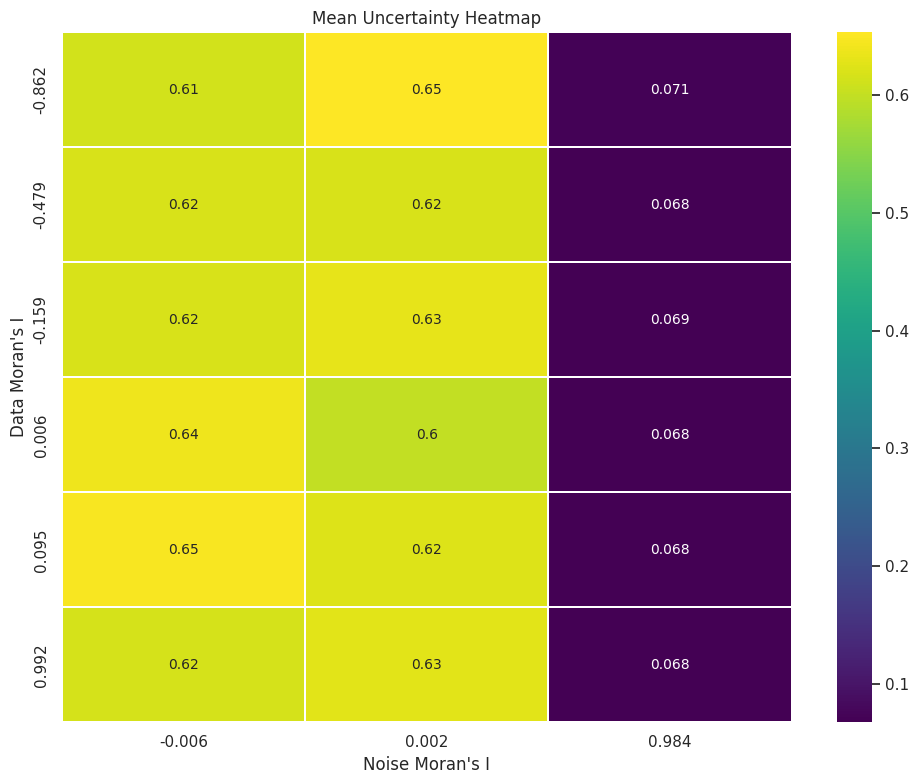

In [ ]:
### ✅ GeoSIMCP 模拟实验可视化模块

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 请将 results_data_noise 列表替换为你运行 geosimcp 实验后的输出
results_data_noise_df = pd.DataFrame(
    results_data_noise,
    columns=[
        'data_moran_type', 'noise_moran', 'data_moran',
        'rmse', 'r2', 'coverage_rate', 'interval_score',
        'mean_uncertainty', 'nrmse'
    ]
)

# 类型转换 & 标准化列名
results_data_noise_df = results_data_noise_df.astype({
    'data_moran_type': str, 'noise_moran': float, 'data_moran': float,
    'rmse': float, 'r2': float, 'coverage_rate': float,
    'interval_score': float, 'mean_uncertainty': float, 'nrmse': float
})
results_data_noise_df['noise_moran_'] = results_data_noise_df['noise_moran'].round(3)
results_data_noise_df['data_moran_'] = results_data_noise_df['data_moran'].round(3)

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1️⃣ Heatmap of NRMSE
f1, ax1 = plt.subplots(figsize=(10, 8))
nrmse_heatmap_data = results_data_noise_df.pivot_table(
    values='nrmse', columns='noise_moran_', index='data_moran_', aggfunc='mean')
sns.heatmap(nrmse_heatmap_data, annot=True, cmap='viridis', linewidths=0.2,
            annot_kws={'fontsize': 10}, ax=ax1)
ax1.set_title('NRMSE Heatmap')
ax1.set_xlabel("Noise Moran's I")
ax1.set_ylabel("Data Moran's I")
plt.tight_layout()

# 2️⃣ Heatmap of Coverage
f2, ax2 = plt.subplots(figsize=(10, 8))
coverage_heatmap_data = results_data_noise_df.pivot_table(
    values='coverage_rate', columns='noise_moran_', index='data_moran_', aggfunc='mean')
sns.heatmap(coverage_heatmap_data, annot=True, cmap='viridis', linewidths=0.2,
            annot_kws={'fontsize': 10}, ax=ax2,
            vmax=results_data_noise_df['coverage_rate'].max(),
            vmin=results_data_noise_df['coverage_rate'].min())
ax2.set_title('Coverage Heatmap')
ax2.set_xlabel("Noise Moran's I")
ax2.set_ylabel("Data Moran's I")
plt.tight_layout()

# 3️⃣ Lineplot of NRMSE vs Noise Moran
f3, ax3 = plt.subplots(figsize=(10, 8))
sns.lineplot(data=results_data_noise_df, x='noise_moran', y='nrmse',
             hue='data_moran_type', ax=ax3, lw=2)
ax3.set_title('NRMSE vs Noise Moran')
ax3.set_xlabel("Noise Moran's I")
ax3.set_ylabel("NRMSE")
plt.tight_layout()

# 4️⃣ Lineplot of Coverage vs Noise Moran
f4, ax4 = plt.subplots(figsize=(10, 8))
sns.lineplot(data=results_data_noise_df, x='noise_moran', y='coverage_rate',
             hue='data_moran_type', ax=ax4)
ax4.set_title('Coverage Rate vs Noise Moran')
ax4.set_xlabel("Noise Moran's I")
ax4.set_ylabel("Coverage Rate")
plt.tight_layout()

# 5️⃣ Heatmap of Interval Score
f5, ax5 = plt.subplots(figsize=(10, 8))
interval_score_heatmap_data = results_data_noise_df.pivot_table(
    values='interval_score', columns='noise_moran_', index='data_moran_', aggfunc='mean')
sns.heatmap(interval_score_heatmap_data, annot=True, cmap='viridis', linewidths=0.2,
            annot_kws={'fontsize': 10}, ax=ax5)
ax5.set_title('Interval Score Heatmap')
ax5.set_xlabel("Noise Moran's I")
ax5.set_ylabel("Data Moran's I")
plt.tight_layout()

# 6️⃣ Heatmap of Mean Uncertainty
f6, ax6 = plt.subplots(figsize=(10, 8))
uncertainty_heatmap_data = results_data_noise_df.pivot_table(
    values='mean_uncertainty', columns='noise_moran_', index='data_moran_', aggfunc='mean')
sns.heatmap(uncertainty_heatmap_data, annot=True, cmap='viridis', linewidths=0.2,
            annot_kws={'fontsize': 10}, ax=ax6)
ax6.set_title('Mean Uncertainty Heatmap')
ax6.set_xlabel("Noise Moran's I")
ax6.set_ylabel("Data Moran's I")
plt.tight_layout()

